# Deep07. mini BERT 만들기

## 루브릭

| 학습목표 | 평가기준 |
|---|---|
| 1. 한글 코퍼스를 가공하여 BERT pretrain용 데이터셋을 잘 생성하였다. | MLM, NSP task의 특징이 잘 반영된 pretrain용 데이터셋 생성과정이 체계적으로 진행되었다. |
| 2. 구현한 BERT 모델의 학습이 안정적으로 진행됨을 확인하였다. | 학습진행 과정 중에 MLM, NSP loss의 안정적인 감소가 확인되었다. |
| 3. 1M짜리 mini BERT 모델의 제작과 학습이 정상적으로 진행되었다. | 학습된 모델 및 학습과정의 시각화 내역이 제출되었다. |


---
# 1. 라이브러리 및 환경 설정

### 1-1. 라이브러리 · 경로 · 시드

In [1]:
import os
import re
import json
import math
import copy
import random
import logging
from collections import Counter

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import sentencepiece as spm
from tqdm.notebook import tqdm
import matplotlib
import matplotlib.pyplot as plt

# 경로
DATA_DIR = './data'
MODEL_DIR = './models'                            # 토크나이저 · 체크포인트
CORPUS_PATH = os.path.join(DATA_DIR, 'kowiki.txt')
HIST_DIR = os.path.join(DATA_DIR, 'history')      # 학습 기록(json)
for d in (DATA_DIR, MODEL_DIR, HIST_DIR):
    os.makedirs(d, exist_ok=True)

SEED = 42

def set_seed(seed=SEED):
    """실험마다 같은 조건에서 시작하도록 모든 난수 시드를 고정한다."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print('device :', device)

device : cuda


### 1-2. matplotlib 한글 폰트

In [2]:
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
matplotlib.rcParams['font.family'] = 'Malgun Gothic'   # Windows 기본 한글 폰트
matplotlib.rcParams['axes.unicode_minus'] = False

### 1-3. 실험 설정

11장 실험 번호별 설정이다. 이전 실험의 학습 기록은 `data/history/{run_name}.json`, 결과 정리는 11장에 작성한다.

In [3]:
EXPERIMENTS = {
    1: dict(run_name='mini_bert',      drop_title=False, split='instance'),     # base
    2: dict(run_name='mini_bert_exp2', drop_title=True,  split='doc'),          # 제목 줄 제거 + 문서 단위 val
}
EXP_ID = 2

RUN_NAME = EXPERIMENTS[EXP_ID]['run_name']          # 체크포인트 · 학습 기록 파일 이름
DROP_TITLE = EXPERIMENTS[EXP_ID]['drop_title']      # True 면 문서 첫 줄(제목)을 빼고 NSP 인스턴스를 만든다
SPLIT = EXPERIMENTS[EXP_ID]['split']                # 'instance' : 인스턴스 단위 무작위 / 'doc' : 문서 단위
print(f'실험 {EXP_ID} | run_name {RUN_NAME} | drop_title {DROP_TITLE} | split {SPLIT}')

실험 2 | run_name mini_bert_exp2 | drop_title True | split doc


---
# 2. 데이터 EDA

### 2-1. 코퍼스 확인

In [44]:
def scan_corpus(path, n_preview=3):
    """코퍼스를 순회해 줄 · 문서 통계와 앞쪽 문서 미리보기를 확인한다.

    빈 줄을 문서 경계로 본다.
    :return: dict(n_lines, n_empty, doc_lines, line_chars, preview)
        doc_lines  : 문서별 줄 수
        line_chars : 비어 있지 않은 줄의 글자 수
        preview    : 앞쪽 n_preview 개 문서의 줄 목록
    """
    n_lines = n_empty = 0
    doc_lines, line_chars, preview = [], [], []
    cur_doc, cur_len = [], 0    # 현재 문서

    def close_doc():
        nonlocal cur_doc, cur_len
        if cur_len:
            doc_lines.append(cur_len)
            if len(preview) < n_preview:
                preview.append(cur_doc)
        cur_doc, cur_len = [], 0

    with open(path, 'r', encoding='utf-8') as f:
        for line in tqdm(f, desc='scan', mininterval=1):
            n_lines += 1
            line = line.strip()
            if not line:            # 빈 줄 -> 문서 경계
                n_empty += 1
                close_doc()
                continue
            line_chars.append(len(line))
            cur_len += 1
            if len(preview) < n_preview:
                cur_doc.append(line)
    close_doc()                     # 마지막 문서

    return dict(n_lines=n_lines, n_empty=n_empty,
                doc_lines=np.array(doc_lines, dtype=np.int32),
                line_chars=np.array(line_chars, dtype=np.int32),
                preview=preview)


stats = scan_corpus(CORPUS_PATH)
doc_lines, line_chars = stats['doc_lines'], stats['line_chars']

print(f"전체 줄        : {stats['n_lines']:,}")
print(f"빈 줄          : {stats['n_empty']:,}")
print(f"내용 줄        : {len(line_chars):,}")
print(f"문서 수        : {len(doc_lines):,}")
print(f"전체 글자 수   : {line_chars.sum():,}")

scan: 0it [00:00, ?it/s]

전체 줄        : 3,957,761
빈 줄          : 1,507,375
내용 줄        : 2,450,386
문서 수        : 502,261
전체 글자 수   : 284,988,903


### 2-2. 문서 확인

문서의 첫 줄이 제목인지, 문서가 빈 줄로 잘 나뉘는지 본다.

In [5]:
for i, doc in enumerate(stats['preview']):
    print(f'--- 문서 {i} ({len(doc)}줄) ---')
    for line in doc[:5]:
        print('   ', line[:100] + (' …' if len(line) > 100 else ''))
    print()

--- 문서 0 (21줄) ---
    지미 카터
    제임스 얼 "지미" 카터 주니어(, 1924년 10월 1일 ~ )는 민주당 출신 미국 39번째 대통령 (1977년 ~ 1981년)이다.
    지미 카터는 조지아주 섬터 카운티 플레인스 마을에서 태어났다. 조지아 공과대학교를 졸업하였다. 그 후 해군에 들어가 전함·원자력·잠수함의 승무원으로 일하였다. 1953년 미국 해군 …
    1962년 조지아 주 상원 의원 선거에서 낙선하나 그 선거가 부정선거 였음을 입증하게 되어 당선되고, 1966년 조지아 주 지사 선거에 낙선하지만 1970년 조지아 주 지사를 역임 …
    1976년 대통령 선거에 민주당 후보로 출마하여 도덕주의 정책으로 내세워, 포드를 누르고 당선되었다.

--- 문서 1 (14줄) ---
    수학
    수학(數學, )은 양, 구조, 공간, 변화, 미적분 등의 개념을 다루는 학문이다. 현대 수학은 형식 논리를 이용해서 공리로 구성된 추상적 구조를 연구하는 학문으로 여겨지기도 한다. …
    수학은 숫자 세기, 계산, 측정 및 물리적 대상의 모양과 움직임을 추상화하고, 이에 논리적 추론을 적용하여 나타났다. 이런 기본 개념들은 고대 이집트, 메소포타미아, 고대 인도,  …
    오늘날 수학은 자연과학, 공학, 의학뿐만 아니라, 경제학 등의 사회과학에서도 중요한 도구로서도 사용된다. 수학을 이런 분야들에 적용한 응용수학은 그 결과로써 수학 자체의 발전을 이 …
    수학 mathematics는 '배우는 모든 것'라는 뜻의 고대 그리스어 mathematikos에서 유래되었다. 줄여서 math라고 표현하기도 한다.

--- 문서 2 (4줄) ---
    수학 상수
    수학에서 상수란 그 값이 변하지 않는 불변량으로, 변수의 반대말이다. 물리 상수와는 달리, 수학 상수는 물리적 측정과는 상관없이 정의된다.
    수학 상수는 대개 실수체나 복소수체의 원소이다. 우리가 이야기할 수 있는 상수는 (거의 대부분 계산 가능한) 정의가능한

### 2-3. 문서당 줄 수

`create_pretrain_instances()`는 문서 안의 줄을 모아 A / B로 나눈다. 줄이 1개뿐인 문서는 A / B를 만들 수 없어 NSP 인스턴스가 생기지 않는다. 이런 문서가 얼마나 되는지 확인한다.

문서당 줄 수 : mean 4.88 | median 3 | p90 9 | p99 36 | max 2,932 (줄)
줄이 1개뿐인 문서 : 4,063 / 502,261 (0.81%)  -> NSP 인스턴스 없음
그 문서들의 줄    : 4,063 / 2,450,386 (0.17%)


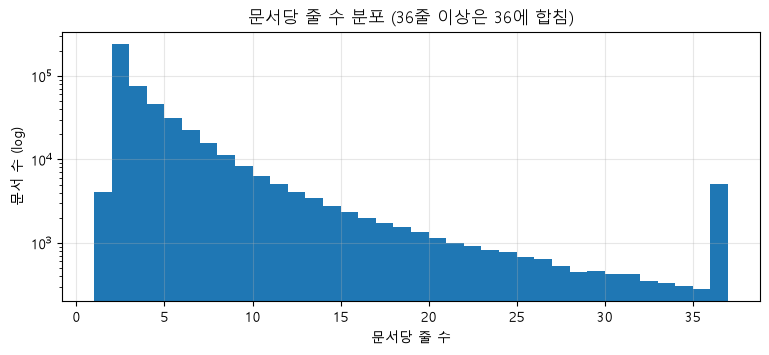

In [6]:
def describe(arr, name, unit):
    """평균 · 중앙값 · p90 · p99 · max 를 출력한다."""
    p50, p90, p99 = np.percentile(arr, [50, 90, 99])
    print(f'{name} : mean {arr.mean():.2f} | median {p50:.0f} | p90 {p90:.0f} | p99 {p99:.0f} | max {arr.max():,} ({unit})')


describe(doc_lines, '문서당 줄 수', '줄')

one = doc_lines == 1
print(f'줄이 1개뿐인 문서 : {one.sum():,} / {len(doc_lines):,} ({one.mean():.2%})  -> NSP 인스턴스 없음')
print(f'그 문서들의 줄    : {doc_lines[one].sum():,} / {doc_lines.sum():,} ({doc_lines[one].sum() / doc_lines.sum():.2%})')

cap = int(np.percentile(doc_lines, 99))
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.hist(np.minimum(doc_lines, cap), bins=range(1, cap + 2))
ax.set_yscale('log')
ax.set_xlabel('문서당 줄 수'); ax.set_ylabel('문서 수 (log)')
ax.set_title(f'문서당 줄 수 분포 ({cap}줄 이상은 {cap}에 합침)')
ax.grid(alpha=.3)
plt.show()

### 2-4. 줄 길이

pretrain 입력은 `n_seq = 128` 토큰이고, `[CLS] A [SEP] B [SEP]`에서 A + B는 최대 125 토큰이다. 이보다 긴 쌍은 `trim_tokens()`로 잘린다.

줄 길이 : mean 116.30 | median 76 | p90 281 | p99 585 | max 9,473 (글자)
  10자 이하 줄 : 19.14%
  50자 이하 줄 : 40.24%
 100자 이하 줄 : 58.30%
 200자 이하 줄 : 80.69%
 500자 이하 줄 : 98.20%


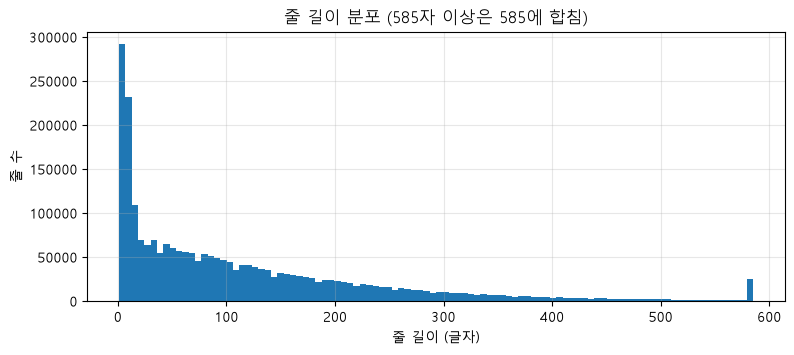

In [7]:
describe(line_chars, '줄 길이', '글자')
for cut in (10, 50, 100, 200, 500):
    print(f'{cut:>4}자 이하 줄 : {(line_chars <= cut).mean():.2%}')

cap = int(np.percentile(line_chars, 99))
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.hist(np.minimum(line_chars, cap), bins=100)
ax.set_xlabel('줄 길이 (글자)'); ax.set_ylabel('줄 수')
ax.set_title(f'줄 길이 분포 ({cap}자 이상은 {cap}에 합침)')
ax.grid(alpha=.3)
plt.show()

### 2-5. EDA 정리

| 확인 항목 | 실행 결과 | 반영 |
|---|---|---|
| 규모 | 총 3,957,761줄 (빈 줄 1,507,375 / 내용 줄 2,450,386) · 문서 502,261개 · 약 2.85억 글자 | 전체를 pretrain json으로 만들고, 학습에는 일부만 memmap으로 로딩 |
| 문서 구분 | 빈 줄로 문서가 나뉘고 첫 줄은 제목. 빈 줄이 문서 수의 약 3배라 빈 줄이 연속으로 나오는 곳도 있음 | NSP 인스턴스는 문서 안에서만 만든다. 연속된 빈 줄은 문서 1개로 끊기만 한다 |
| 문서당 줄 수 | 평균 4.88 · 중앙값 3 · p90 9 · p99 36 · 최대 2,932줄. 줄 1개뿐인 문서 4,063개 (0.81%, 줄 기준 0.17%) | 버려지는 양이 작아 따로 처리하지 않는다 |
| 줄 길이 | 평균 116 · 중앙값 76 · p90 281 · p99 585 · 최대 9,473자. 10자 이하 19.14% · 200자 이하 80.69% · 500자 이하 98.20% | 10자 이하 줄 비율이 제목 줄 비율(문서 수 / 내용 줄 = 20.5%)과 비슷해 대부분 제목으로 보인다. 긴 줄은 `trim_tokens()`로 잘린다. 토큰 수는 3-3에서 확인 |

---
# 3. Tokenizer (SentencePiece, vocab 8000)

- `kowiki.txt`로 BPE 모델을 학습해 `models/ko_8000.model`로 저장한다.
- 특수 토큰: `[PAD]=0 [UNK]=1 [BOS]=2 [EOS]=3`, `user_defined_symbols=[SEP],[CLS],[MASK]`
- proj 노트북과 같이 `vocab_size + 7`을 넘겨 **일반 토큰 8,000개 + 특수 토큰 7개 = 8,007개**로 만든다.

### 3-1. SentencePiece 학습

In [8]:
import sentencepiece as spm
import os

prefix = './models/ko_8000'
vocab_size = 8000
spm.SentencePieceTrainer.train(f"--input={CORPUS_PATH} --model_prefix={prefix} --vocab_size={vocab_size + 7} --model_type=bpe --max_sentence_length=999999 --pad_id=0 --pad_piece=[PAD] --unk_id=1 --unk_piece=[UNK] --bos_id=2 --bos_piece=[BOS] --eos_id=3 --eos_piece=[EOS] --user_defined_symbols=[SEP],[CLS],[MASK]")

True

### 3-2. 로드 · 특수 토큰 id · vocab 크기 확인

In [9]:
vocab = spm.SentencePieceProcessor()
vocab.load(f"{MODEL_DIR}/ko_8000.model")

True

In [10]:
SPECIAL_TOKENS = ['[PAD]', '[UNK]', '[BOS]', '[EOS]', '[SEP]', '[CLS]', '[MASK]']

for piece in SPECIAL_TOKENS:
    print(f'{piece:<7}: {vocab.piece_to_id(piece)}')
print(f'\nvocab 크기 : {len(vocab):,} (특수 토큰 {len(SPECIAL_TOKENS)} + 일반 토큰 {len(vocab) - len(SPECIAL_TOKENS):,})')

assert [vocab.piece_to_id(p) for p in SPECIAL_TOKENS] == list(range(len(SPECIAL_TOKENS)))

[PAD]  : 0
[UNK]  : 1
[BOS]  : 2
[EOS]  : 3
[SEP]  : 4
[CLS]  : 5
[MASK] : 6

vocab 크기 : 8,007 (특수 토큰 7 + 일반 토큰 8,000)


### 3-3. 토큰화 예시 · 토큰 길이 분포

In [11]:
# EDA 에서 본 첫 문서의 연속된 두 줄을 A / B 로 쓴다
string_a, string_b = stats['preview'][0][1], stats['preview'][0][2]
tokens_a = vocab.encode_as_pieces(string_a)
tokens_b = vocab.encode_as_pieces(string_b)
tokens_org = ['[CLS]'] + tokens_a + ['[SEP]'] + tokens_b + ['[SEP]']

print(f'A : {len(tokens_a)}토큰')
print(f'B : {len(tokens_b)}토큰')
print(f'[CLS] A [SEP] B [SEP] : {len(tokens_org)}토큰\n')
print(tokens_org)
print(vocab.encode_as_ids(string_a))

A : 39토큰
B : 99토큰
[CLS] A [SEP] B [SEP] : 141토큰

['[CLS]', '▁제임스', '▁얼', '▁"', '지', '미', '"', '▁카', '터', '▁주', '니어', '(,', '▁192', '4', '년', '▁10', '월', '▁1', '일', '▁~', '▁)', '는', '▁민주', '당', '▁출신', '▁미국', '▁3', '9', '번째', '▁대통령', '▁(19', '7', '7', '년', '▁~', '▁1981', '년', ')', '이다', '.', '[SEP]', '▁지', '미', '▁카', '터', '는', '▁조지', '아', '주', '▁섬', '터', '▁카운', '티', '▁플', '레', '인', '스', '▁마을', '에서', '▁태어났다', '.', '▁조지', '아', '▁공', '과', '대학교', '를', '▁졸업', '하였다', '.', '▁그', '▁후', '▁해', '군에', '▁들어가', '▁전', '함', '·', '원', '자', '력', '·', '잠', '수', '함', '의', '▁승', '무', '원으로', '▁일', '하였다', '.', '▁195', '3', '년', '▁미국', '▁해군', '▁대', '위로', '▁예', '편', '하였고', '▁이후', '▁땅', '콩', '·', '면', '화', '▁등을', '▁가', '꿔', '▁많은', '▁돈', '을', '▁벌', '었다', '.', '▁그의', '▁별', '명이', '▁"', '땅', '콩', '▁농', '부', '"', '▁(', 'P', 'e', 'an', 'ut', '▁F', 'ar', 'm', 'er', ')', '로', '▁알려', '졌다', '.', '[SEP]']
[3324, 1042, 104, 3610, 3686, 3718, 207, 3714, 37, 3417, 416, 810, 3666, 3625, 160, 3662, 7, 3629, 203, 241, 3602, 1114,

sample: 0it [00:00, ?it/s]

샘플 줄 : 122,704
줄 토큰 수 : mean 65.30 | median 42 | p90 157 | p99 329 | max 2,485 (토큰)
토큰당 글자 수 : 1.77
  32토큰 이하 줄 : 43.09%
  64토큰 이하 줄 : 62.84%
 125토큰 이하 줄 : 84.22%


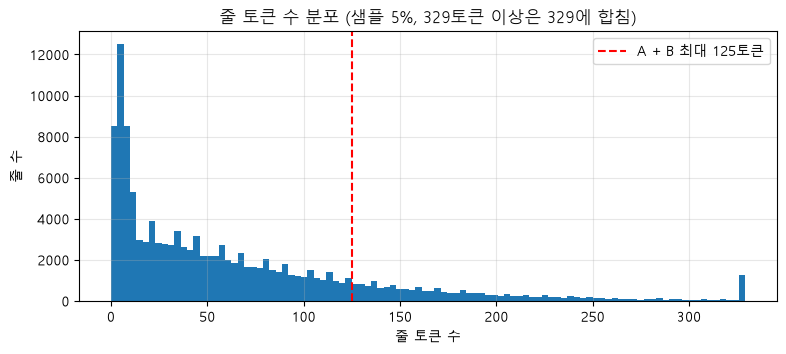

In [12]:
def sample_lines(path, ratio=0.05, seed=SEED):
    """비어 있지 않은 줄을 ratio 비율로 무작위 추출한다."""
    rng = random.Random(seed)
    lines = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in tqdm(f, desc='sample', mininterval=1):
            line = line.strip()
            if line and rng.random() < ratio:
                lines.append(line)
    return lines


sample = sample_lines(CORPUS_PATH)
tok_len = np.array([len(ids) for ids in vocab.encode(sample)], dtype=np.int32)
chr_len = np.array([len(s) for s in sample], dtype=np.int32)

MAX_AB = 128 - 3    # n_seq 128 에서 [CLS] [SEP] [SEP] 를 뺀 A + B 최대 길이

print(f'샘플 줄 : {len(sample):,}')
describe(tok_len, '줄 토큰 수', '토큰')
print(f'토큰당 글자 수 : {chr_len.sum() / tok_len.sum():.2f}')
for cut in (32, 64, MAX_AB):
    print(f'{cut:>4}토큰 이하 줄 : {(tok_len <= cut).mean():.2%}')

cap = int(np.percentile(tok_len, 99))
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.hist(np.minimum(tok_len, cap), bins=100)
ax.axvline(MAX_AB, color='r', ls='--', label=f'A + B 최대 {MAX_AB}토큰')
ax.set_xlabel('줄 토큰 수'); ax.set_ylabel('줄 수')
ax.set_title(f'줄 토큰 수 분포 (샘플 5%, {cap}토큰 이상은 {cap}에 합침)')
ax.legend(); ax.grid(alpha=.3)
plt.show()

### 3-4. `vocab_list`

In [13]:
# [MASK] 대상 중 10% 를 바꿔 넣을 random token 후보. 특수 토큰(id 0~6)은 제외한다.
vocab_list = []
for i in range(len(SPECIAL_TOKENS), len(vocab)):
    if not vocab.is_unknown(i):
        vocab_list.append(vocab.id_to_piece(i))

print(f'vocab_list : {len(vocab_list):,}개')
print(vocab_list[:10])

vocab_list : 8,000개
['▁1', '▁이', '으로', '에서', '▁있', '▁2', '▁그', '▁대', '▁사', '이다']


---
# 4. 데이터 전처리 (1) MASK 생성

- 전체 토큰의 15%를 마스킹한다. subword 하나만 가리면 너무 쉽게 맞추므로 띄어쓰기(`▁`) 단위로 한꺼번에 가린다.
- 마스킹한 토큰 중 80% `[MASK]` / 10% random 토큰 / 10% 원래 토큰

### 4-1. `create_pretrain_mask()`

In [14]:
def create_pretrain_mask(tokens, mask_cnt, vocab_list):
    """
    띄어쓰기(▁) 단위로 단어를 골라 MLM 마스크를 만든다. 고른 단어마다 80% [MASK] / 10% 원래 토큰 / 10% random token 으로 바꾼다.
    :param tokens: [CLS] A [SEP] B [SEP] tokens. 이 list 를 직접 바꾼다
    :param mask_cnt: 마스킹할 최대 토큰 수 (호출하는 쪽에서 특수 토큰 3개를 뺀 길이의 15% 를 내림해 넘긴다)
    :param vocab_list: random token 후보 (특수 토큰 제외)
    :return tokens: 마스킹된 tokens (입력 list 와 같은 객체)
    :return mask_idx: 마스킹한 위치 (오름차순)
    :return mask_label: 마스킹한 위치의 원래 토큰
    """
    # 단어 단위로 mask 하기 위해서 index 분할 (띄어쓰기)
    cand_idx = []
    for (i, token) in enumerate(tokens):
        if token == "[CLS]" or token == "[SEP]":
            continue
        if 0 < len(cand_idx) and not token.startswith(u"\u2581"):
            cand_idx[-1].append(i)
        else:
            cand_idx.append([i])

    # random mask를 위해서 순서를 섞음 (shuffle)
    random.shuffle(cand_idx)
    mask_lms = []
    for index_set in cand_idx:
        if len(mask_lms) >= mask_cnt:
            break
        if len(mask_lms) + len(index_set) > mask_cnt:
            continue
        dice = random.random()      # 단어 단위로 한 번 뽑아 단어 안의 토큰은 같은 방식으로 바꾼다
        for index in index_set:
            if dice < 0.8:              # 80% : [MASK]
                masked_token = "[MASK]"
            elif dice < 0.9:            # 10% : 원래 토큰 유지
                masked_token = tokens[index]
            else:                       # 10% : random token
                masked_token = random.choice(vocab_list)
            mask_lms.append({"index": index, "label": tokens[index]})
            tokens[index] = masked_token

    # mask_lms 정렬 후 mask_idx, mask_label 추출 (sorted 사용)
    mask_lms = sorted(mask_lms, key=lambda x: x["index"])
    mask_idx = [p["index"] for p in mask_lms]
    mask_label = [p["label"] for p in mask_lms]

    return tokens, mask_idx, mask_label

### 4-2. 결과 확인

In [15]:
set_seed()                                  # 재실행해도 같은 예시가 나오도록
tokens = copy.deepcopy(tokens_org)          # create_pretrain_mask() 가 tokens 를 직접 바꾸므로 복사
mask_cnt = int((len(tokens) - 3) * 0.15)    # [CLS] [SEP] [SEP] 를 뺀 토큰의 15%

tokens, mask_idx, mask_label = create_pretrain_mask(tokens, mask_cnt, vocab_list)

print("tokens_org")
print(tokens_org, "\n")
print("tokens")
print(tokens, "\n")

print("mask_idx   :", mask_idx)
print("mask_label :", mask_label)

tokens_org
['[CLS]', '▁제임스', '▁얼', '▁"', '지', '미', '"', '▁카', '터', '▁주', '니어', '(,', '▁192', '4', '년', '▁10', '월', '▁1', '일', '▁~', '▁)', '는', '▁민주', '당', '▁출신', '▁미국', '▁3', '9', '번째', '▁대통령', '▁(19', '7', '7', '년', '▁~', '▁1981', '년', ')', '이다', '.', '[SEP]', '▁지', '미', '▁카', '터', '는', '▁조지', '아', '주', '▁섬', '터', '▁카운', '티', '▁플', '레', '인', '스', '▁마을', '에서', '▁태어났다', '.', '▁조지', '아', '▁공', '과', '대학교', '를', '▁졸업', '하였다', '.', '▁그', '▁후', '▁해', '군에', '▁들어가', '▁전', '함', '·', '원', '자', '력', '·', '잠', '수', '함', '의', '▁승', '무', '원으로', '▁일', '하였다', '.', '▁195', '3', '년', '▁미국', '▁해군', '▁대', '위로', '▁예', '편', '하였고', '▁이후', '▁땅', '콩', '·', '면', '화', '▁등을', '▁가', '꿔', '▁많은', '▁돈', '을', '▁벌', '었다', '.', '▁그의', '▁별', '명이', '▁"', '땅', '콩', '▁농', '부', '"', '▁(', 'P', 'e', 'an', 'ut', '▁F', 'ar', 'm', 'er', ')', '로', '▁알려', '졌다', '.', '[SEP]'] 

tokens
['[CLS]', '▁제임스', '▁얼', '▁"', '지', '미', '"', '▁카', '터', '▁주', '니어', '(,', '▁192', '4', '년', '▁10', '월', '▁1', '일', '▁~', '[MASK]', '[MASK]', '▁민주', '

### 4-3. 검증: 마스킹 비율 · 80 / 10 / 10 비율

인스턴스 : 5,000 | 마스킹 후보 토큰 : 408,093 | 마스킹된 토큰 : 58,180
전체 마스킹 비율 : 14.26% (목표 15%)
인스턴스별 마스킹 비율 : mean 13.57 | median 14 | p90 15 | p99 15 | max 15.0 (%)
일부만 가려진 단어 : 0 | 가려진 [CLS] / [SEP] : 0



,개수,비율,목표
[MASK],"46,574",80.05%,80%
random,"5,662",9.73%,10%
원래 토큰,"5,944",10.22%,10%


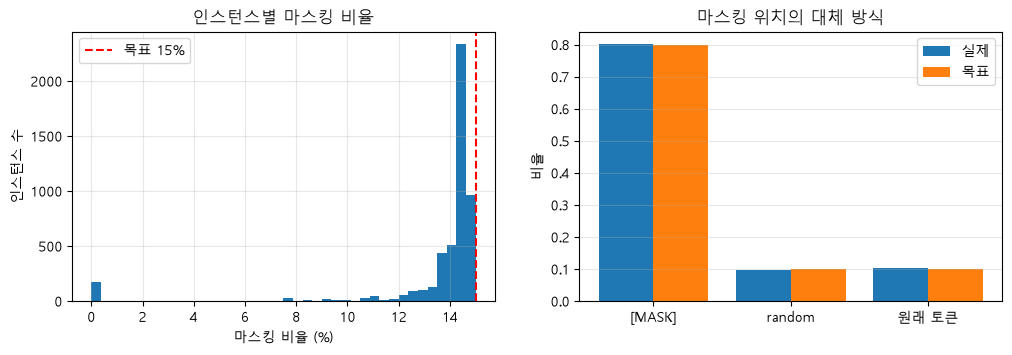

In [16]:
def word_groups(tokens):
    """create_pretrain_mask() 와 같은 기준으로 [CLS] / [SEP] 를 뺀 토큰을 띄어쓰기 단위로 묶는다."""
    groups = []
    for i, token in enumerate(tokens):
        if token in ('[CLS]', '[SEP]'):
            continue
        if groups and not token.startswith('\u2581'):
            groups[-1].append(i)
        else:
            groups.append([i])
    return groups


def mask_stats(lines, n_pairs=5000, mask_prob=0.15, seed=SEED):
    """샘플 줄 2개씩으로 [CLS] A [SEP] B [SEP] 를 만들어 마스킹하고 결과를 집계한다.

    A / B 길이는 단순히 앞에서 잘라 A + B <= MAX_AB 로 맞춘다 (실제 자르기는 5-1 trim_tokens).
    """
    set_seed(seed)
    pairs = random.Random(seed).sample(lines, 2 * n_pairs)
    n_cand = n_masked = 0
    kinds = Counter()           # 마스킹 위치가 무엇으로 바뀌었는지
    ratios = []                 # 인스턴스별 마스킹 비율
    broken_words = special_masked = 0

    for k in range(n_pairs):
        a = vocab.encode_as_pieces(pairs[2 * k])[:MAX_AB // 2]
        b = vocab.encode_as_pieces(pairs[2 * k + 1])[:MAX_AB - len(a)]
        org = ['[CLS]'] + a + ['[SEP]'] + b + ['[SEP]']
        mask_cnt = int((len(org) - 3) * mask_prob)
        masked, mask_idx, mask_label = create_pretrain_mask(copy.deepcopy(org), mask_cnt, vocab_list)

        n_cand += len(org) - 3
        n_masked += len(mask_idx)
        ratios.append(len(mask_idx) / (len(org) - 3))
        for idx, label in zip(mask_idx, mask_label):
            if masked[idx] == '[MASK]':
                kinds['[MASK]'] += 1
            elif masked[idx] == label:
                kinds['원래 토큰'] += 1
            else:
                kinds['random'] += 1

        # 한 단어는 전부 가려지거나 전부 남아야 한다
        idx_set = set(mask_idx)
        broken_words += sum(0 < len(idx_set & set(g)) < len(g) for g in word_groups(org))
        special_masked += sum(org[i] in ('[CLS]', '[SEP]') for i in mask_idx)

    return dict(n_pairs=n_pairs, n_cand=n_cand, n_masked=n_masked, kinds=kinds,
                ratios=np.array(ratios), broken_words=broken_words, special_masked=special_masked)


ms = mask_stats(sample)

print(f"인스턴스 : {ms['n_pairs']:,} | 마스킹 후보 토큰 : {ms['n_cand']:,} | 마스킹된 토큰 : {ms['n_masked']:,}")
print(f"전체 마스킹 비율 : {ms['n_masked'] / ms['n_cand']:.2%} (목표 15%)")
describe(ms['ratios'] * 100, '인스턴스별 마스킹 비율', '%')
print(f"일부만 가려진 단어 : {ms['broken_words']} | 가려진 [CLS] / [SEP] : {ms['special_masked']}\n")

order = ['[MASK]', 'random', '원래 토큰']
kind_df = pd.DataFrame({'개수': [ms['kinds'][k] for k in order]}, index=order)
kind_df['비율'] = kind_df['개수'] / kind_df['개수'].sum()
kind_df['목표'] = [0.8, 0.1, 0.1]
display(kind_df.style.format({'개수': '{:,}', '비율': '{:.2%}', '목표': '{:.0%}'}))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].hist(ms['ratios'] * 100, bins=40)
axes[0].axvline(15, color='r', ls='--', label='목표 15%')
axes[0].set_xlabel('마스킹 비율 (%)'); axes[0].set_ylabel('인스턴스 수')
axes[0].set_title('인스턴스별 마스킹 비율'); axes[0].legend(); axes[0].grid(alpha=.3)

x = np.arange(len(order))
axes[1].bar(x - 0.2, kind_df['비율'], width=0.4, label='실제')
axes[1].bar(x + 0.2, kind_df['목표'], width=0.4, label='목표')
axes[1].set_xticks(x, order); axes[1].set_ylabel('비율')
axes[1].set_title('마스킹 위치의 대체 방식'); axes[1].legend(); axes[1].grid(alpha=.3, axis='y')
plt.show()

**4-3 결과**

| 확인 항목 | 결과 | 목표 |
|---|---|---|
| 전체 마스킹 비율 | 14.26% (58,180 / 408,093 토큰) | 15% |
| 인스턴스별 마스킹 비율 | 평균 13.57% · 중앙값 14% · 최대 15% | 15% |
| `[MASK]` / random / 원래 토큰 | 80.05% / 9.73% / 10.22% | 80% / 10% / 10% |
| 일부만 가려진 단어 | 0 | 0 |
| 가려진 `[CLS]` / `[SEP]` | 0 | 0 |

- 대체 방식은 80 / 10 / 10에 맞고, 마스킹은 항상 단어 단위이며 특수 토큰은 가려지지 않는다.
- 마스킹 비율이 15%를 넘지 않고 조금 낮다. `mask_cnt = int(...)`로 내림하고, 단어가 남은 개수보다 길면 건너뛰기 때문이다. 내림으로 잃는 비율은 짧은 인스턴스일수록 크다.

---
# 5. 데이터 전처리 (2) NSP pair 생성

- 문서 안의 연속된 줄을 A / B로 나누고, **50% 확률로 순서를 뒤집어** NotNext를 만든다.
- `[CLS] A [SEP] B [SEP]`, segment는 A = 0, B = 1
- 같은 인스턴스에 `create_pretrain_mask()`를 적용해 **MLM과 NSP를 한 데이터로** 만든다.

### 5-1. `trim_tokens()`

In [17]:
def trim_tokens(tokens_a, tokens_b, max_seq):
    """
    len(tokens_a) + len(tokens_b) <= max_seq 가 될 때까지 긴 쪽을 한 토큰씩 자른다. 두 list 를 직접 바꾸고 반환값은 없다.
    A 는 앞에서, B 는 뒤에서 잘라 A / B 가 맞닿는 부분은 남긴다.
    :param tokens_a: tokens A
    :param tokens_b: tokens B
    :param max_seq: A + B 최대 길이 (n_seq - 3)
    """
    while True:
        total_length = len(tokens_a) + len(tokens_b)
        if total_length <= max_seq:
            break

        # 긴 쪽을 한 토큰씩 줄인다
        if len(tokens_a) > len(tokens_b):
            del tokens_a[0]     # A 는 앞에서 자른다
        else:
            tokens_b.pop()      # B 는 뒤에서 자른다

### 5-2. `create_pretrain_instances()`

In [18]:
def create_pretrain_instances(vocab, doc, n_seq, mask_prob, vocab_list):
    """
    문서 하나로 pretrain 인스턴스(NSP pair + MLM mask)를 만든다.
    줄을 모으다가 2줄 이상이면서 max_seq 토큰 이상 모이거나 문서 끝에 닿으면 A / B 로 나눈다. 문서 끝에 1줄만 남으면 버린다.
    :param vocab: vocab (함수 안에서는 쓰지 않는다)
    :param doc: 문서 (줄 단위 tokens 의 list). 토큰이 0개인 줄은 A / B 가 빌 수 있으므로 encode_doc() 에서 미리 뺀다
    :param n_seq: 시퀀스 최대 길이
    :param mask_prob: mask 비율 (0.15)
    :param vocab_list: vocab list (random token 용)
    :return instances: dict(tokens, segment, is_next, mask_idx, mask_label) 의 list
    """
    # [CLS], [SEP], [SEP]
    max_seq = n_seq - 3

    instances = []
    current_chunk = []  # line 단위 tokens
    current_length = 0
    for i in range(len(doc)):
        current_chunk.append(doc[i])
        current_length += len(doc[i])
        # 2줄 이상 모였고, 마지막 줄이거나 max_seq 이상 모이면 A / B 로 나눈다
        if 1 < len(current_chunk) and (i == len(doc) - 1 or current_length >= max_seq):
            # A 에 들어갈 줄 수 (A, B 모두 최소 1줄)
            a_end = random.randrange(1, len(current_chunk))
            tokens_a = []
            for j in range(a_end):
                tokens_a.extend(current_chunk[j])
            tokens_b = []
            for j in range(a_end, len(current_chunk)):
                tokens_b.extend(current_chunk[j])

            # 50% 확률로 A / B 순서를 뒤집어 NotNext 를 만든다
            if random.random() < 0.5:
                is_next = 0
                tokens_a, tokens_b = tokens_b, tokens_a
            else:
                is_next = 1
            trim_tokens(tokens_a, tokens_b, max_seq)
            assert 0 < len(tokens_a)
            assert 0 < len(tokens_b)

            # segment : [CLS] A [SEP] = 0, B [SEP] = 1
            tokens = ["[CLS]"] + tokens_a + ["[SEP]"] + tokens_b + ["[SEP]"]
            segment = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)
            # 같은 인스턴스에 MLM mask 를 적용한다
            tokens, mask_idx, mask_label = create_pretrain_mask(tokens, int((len(tokens) - 3) * mask_prob), vocab_list)

            instance = {
                "tokens": tokens,
                "segment": segment,
                "is_next": is_next,
                "mask_idx": mask_idx,
                "mask_label": mask_label
            }
            instances.append(instance)

            current_chunk = []
            current_length = 0
    return instances

### 5-3. 결과 확인 · 검증

In [19]:
N_SEQ = 128

def show_instance(inst):
    """segment 로 A / B 를 나눠 인스턴스를 보여준다."""
    tokens, segment = inst['tokens'], inst['segment']
    a = [t for t, s in zip(tokens, segment) if s == 0]
    b = [t for t, s in zip(tokens, segment) if s == 1]
    label = 'IsNext' if inst['is_next'] else 'NotNext'
    print(f"is_next {inst['is_next']} ({label}) | 길이 {len(tokens)} (A {len(a) - 2} / B {len(b) - 1}) | mask {len(inst['mask_idx'])}")
    print('  A :', ' '.join(a))
    print('  B :', ' '.join(b))
    print('  mask_label :', inst['mask_label'])


def encode_doc(lines):
    """문서의 줄들을 토큰화한다. 토큰이 0개인 줄은 버린다."""
    doc = []
    for line in lines:
        pieces = vocab.encode_as_pieces(line)
        if pieces:
            doc.append(pieces)
    return doc


# 첫 문서 확인 (DROP_TITLE 이면 제목 줄을 뺀다)
set_seed()
doc = encode_doc(stats['preview'][0][1:] if DROP_TITLE else stats['preview'][0])
instances = create_pretrain_instances(vocab, doc, N_SEQ, 0.15, vocab_list)

print(f'문서 {len(doc)}줄 -> 인스턴스 {len(instances)}개\n')
for inst in instances[:3]:
    show_instance(inst)
    print()

문서 20줄 -> 인스턴스 8개

is_next 0 (NotNext) | 길이 128 (A 86 / B 39) | mask 18
  A : [CLS] 레 인 스 ▁마을 에서 ▁태어났다 . ▁조지 아 ▁공 과 대학교 를 ▁졸업 하였다 . ▁그 ▁후 ▁해 군에 [MASK] ▁전 함 · 원 자 력 · 잠 수 함 의 ▁승 무 원으로 ▁일 하였다 . ▁195 3 년 ▁미국 ▁해군 ▁대 위로 ▁예 편 하였고 ▁이후 [MASK] [MASK] [MASK] [MASK] [MASK] ▁등을 ▁가 꿔 ▁많은 ▁돈 을 ▁벌 었다 . ▁그의 ▁별 명이 ▁" 땅 콩 ▁농 부 " ▁( P e an ut ▁F ar m er ) 로 ▁알려 졌다 . [SEP]
  B : ▁제임스 ▁얼 ▁" 지 미 " ▁카 터 ▁주 니어 (, ▁192 4 년 ▁10 월 [MASK] [MASK] ▁~ ▁) 는 ▁민주 당 ▁출신 [MASK] ▁3 9 번째 ▁대통령 ▁(19 7 7 년 [MASK] ▁1981 년 ) 이다 . [SEP]
  mask_label : ['▁들어가', '▁땅', '콩', '·', '면', '화', '▁가', '꿔', '▁F', 'ar', 'm', 'er', ')', '로', '▁1', '일', '▁미국', '▁~']

is_next 1 (IsNext) | 길이 128 (A 97 / B 28) | mask 18
  A : [CLS] [MASK] ▁주 ▁상 원 [MASK] ▁선거 에서 ▁낙 선 하나 ▁그 ▁선거 가 ▁부정 선거 ▁후에 릴 착 ▁입 증 하게 [MASK] ▁당선 되고 , ▁196 6 년 ▁조지 아 ▁주 ▁지 사 ▁선거 에 ▁낙 선 하지만 ▁1970 년 [MASK] [MASK] ▁주 ▁지 사를 ▁역임 했다 . ▁대통령 이 ▁되 기 ▁전 ▁조지 아 주 ▁상 원의 원을 ▁두 번 [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] ▁1975 년까지 ▁조지 아 ▁지 사로 ▁근무 했다 . ▁조지 아 ▁주 지 사로 ▁지 내 면서 , ▁미국 에 ▁사는 ▁흑 인 ▁등 용 법

sample docs: 0it [00:00, ?it/s]

instances:   0%|          | 0/5023 [00:00<?, ?it/s]

샘플 문서 : 5,023 | 인스턴스 : 6,362 | 문서당 인스턴스 평균 1.27
is_next : IsNext 49.76% / NotNext 50.24% (목표 50%)
마스킹 비율 : 인스턴스 평균 14.36% (목표 15%)
규칙 위반 : 없음 (6,362개 모두 길이 · 특수 토큰 위치 · segment 경계 · 빈 A / B 검사 통과)


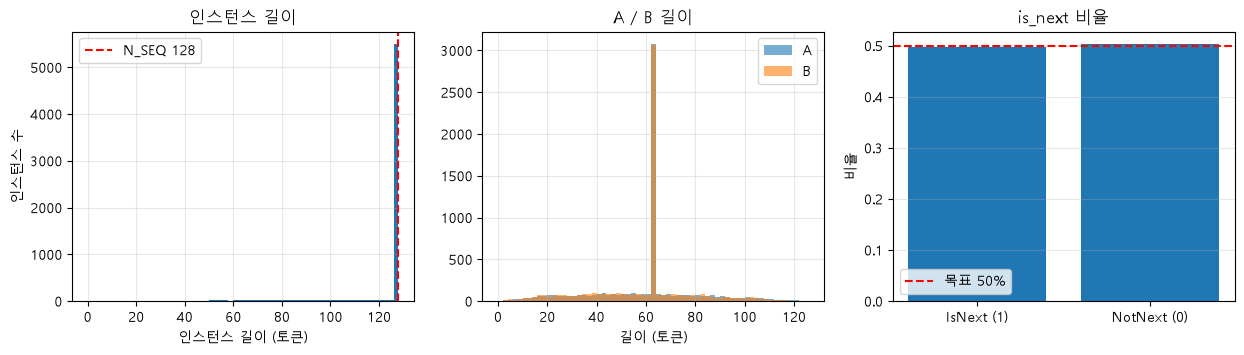

In [20]:
def sample_docs(path, ratio=0.01, seed=SEED):
    """문서(빈 줄로 구분)를 ratio 비율로 무작위 추출해 줄 목록의 list 로 돌려준다."""
    rng = random.Random(seed)
    docs, cur = [], []
    with open(path, 'r', encoding='utf-8') as f:
        for line in tqdm(f, desc='sample docs', mininterval=1):
            line = line.strip()
            if line:
                cur.append(line)
            elif cur:
                if rng.random() < ratio:
                    docs.append(cur)
                cur = []
    if cur and rng.random() < ratio:
        docs.append(cur)
    return docs


def check_instance(inst, n_seq):
    """[CLS] A [SEP] B [SEP] · segment 0 / 1 규칙에서 어긋난 항목 이름을 돌려준다."""
    tokens, segment = inst['tokens'], inst['segment']
    errors = []
    if len(tokens) > n_seq:
        errors.append('길이 초과')
    if len(segment) != len(tokens):
        errors.append('segment 길이')
    if tokens[0] != '[CLS]' or tokens[-1] != '[SEP]' or tokens.count('[CLS]') != 1 or tokens.count('[SEP]') != 2:
        errors.append('특수 토큰 위치')
    else:
        sep = tokens.index('[SEP]')     # A 끝의 [SEP]
        if segment != [0] * (sep + 1) + [1] * (len(tokens) - sep - 1):
            errors.append('segment 경계')
        if sep < 2 or len(tokens) - sep < 3:
            errors.append('빈 A / B')
    return errors


docs = sample_docs(CORPUS_PATH)

set_seed()
all_inst, n_inst_per_doc = [], []
for d in tqdm(docs, desc='instances'):
    inst = create_pretrain_instances(vocab, encode_doc(d[1:] if DROP_TITLE else d), N_SEQ, 0.15, vocab_list)
    all_inst.extend(inst)
    n_inst_per_doc.append(len(inst))
n_inst_per_doc = np.array(n_inst_per_doc)

is_next = np.array([x['is_next'] for x in all_inst])
lengths = np.array([len(x['tokens']) for x in all_inst])
len_a = np.array([x['segment'].count(0) - 2 for x in all_inst])     # [CLS], [SEP] 제외
len_b = np.array([x['segment'].count(1) - 1 for x in all_inst])     # [SEP] 제외
mask_ratio = np.array([len(x['mask_idx']) / (len(x['tokens']) - 3) for x in all_inst])
errors = Counter(e for x in all_inst for e in check_instance(x, N_SEQ))

print(f'샘플 문서 : {len(docs):,} | 인스턴스 : {len(all_inst):,} | 문서당 인스턴스 평균 {n_inst_per_doc.mean():.2f}')
print(f'is_next : IsNext {is_next.mean():.2%} / NotNext {1 - is_next.mean():.2%} (목표 50%)')
print(f'마스킹 비율 : 인스턴스 평균 {mask_ratio.mean():.2%} (목표 15%)')
print('규칙 위반 :', dict(errors) if errors else f'없음 ({len(all_inst):,}개 모두 길이 · 특수 토큰 위치 · segment 경계 · 빈 A / B 검사 통과)')

fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
axes[0].hist(lengths, bins=range(0, N_SEQ + 2, 2))
axes[0].axvline(N_SEQ, color='r', ls='--', label=f'N_SEQ {N_SEQ}')
axes[0].set_xlabel('인스턴스 길이 (토큰)'); axes[0].set_ylabel('인스턴스 수')
axes[0].set_title('인스턴스 길이'); axes[0].legend(); axes[0].grid(alpha=.3)

axes[1].hist(len_a, bins=range(0, N_SEQ, 2), alpha=.6, label='A')
axes[1].hist(len_b, bins=range(0, N_SEQ, 2), alpha=.6, label='B')
axes[1].set_xlabel('길이 (토큰)'); axes[1].set_title('A / B 길이'); axes[1].legend(); axes[1].grid(alpha=.3)

axes[2].bar(['IsNext (1)', 'NotNext (0)'], [is_next.mean(), 1 - is_next.mean()])
axes[2].axhline(0.5, color='r', ls='--', label='목표 50%')
axes[2].set_ylabel('비율'); axes[2].set_title('is_next 비율'); axes[2].legend(); axes[2].grid(alpha=.3, axis='y')
plt.show()

---
# 6. 데이터 전처리 (3) 데이터셋 완성

- 기존 `data/bert_pre_train.json`은 ko_32000 조각이라 vocab 8000에서는 `[UNK]`가 되므로 **새로 생성**한다 → `data/bert_pre_train_8000.json` (`DROP_TITLE`이면 `data/bert_pre_train_8000_notitle.json`)
- 인스턴스마다 문서 번호 `doc_id`를 저장해 8-3에서 문서 단위로 train / val을 나눌 수 있게 한다 (실험 1 json은 이 기능 전에 만들어 `doc_id`가 없다).
- 파일이 크므로 `np.memmap`으로 로딩한다. memmap 파일은 `data/` 아래에 둔다.

### 6-1. `make_pretrain_data()`

In [46]:
def make_pretrain_data(vocab, vocab_list, in_file, out_file, n_seq, mask_prob=0.15, n_lines=None, drop_title=False):
    """
    코퍼스 전체로 pretrain 데이터를 만들어 json lines(한 줄에 인스턴스 1개)로 저장한다.
    인스턴스마다 문서 번호 doc_id 를 함께 저장한다.
    :param vocab: vocab
    :param vocab_list: vocab list (random token 용)
    :param in_file: 코퍼스 파일 (빈 줄로 문서 구분)
    :param out_file: 저장할 json 파일
    :param n_seq: 시퀀스 최대 길이
    :param mask_prob: mask 비율
    :param n_lines: 코퍼스 줄 수 (tqdm 진행 표시용)
    :param drop_title: True 면 문서의 첫 줄(제목)을 빼고 인스턴스를 만든다
    :return n_instances: 저장한 인스턴스 수
    """
    n_instances = 0
    doc_id = 0                      # 코퍼스 안의 문서 순번
    tmp_file = out_file + '.tmp'    # 중간에 멈추면 불완전한 파일이 out_file 로 남지 않도록 임시 파일에 쓴다

    def save_pretrain_instances(out_f, lines):
        nonlocal n_instances, doc_id
        if drop_title:
            lines = lines[1:]
        # encode_doc() : 토큰이 0개인 줄('\u200b' 등)을 버린다
        instances = create_pretrain_instances(vocab, encode_doc(lines), n_seq, mask_prob, vocab_list)
        for instance in instances:
            instance['doc_id'] = doc_id
            out_f.write(json.dumps(instance, ensure_ascii=False))
            out_f.write("\n")
        n_instances += len(instances)
        doc_id += 1

    with open(in_file, "r", encoding='utf-8') as in_f, open(tmp_file, "w", encoding='utf-8') as out_f:
        lines = []                  # 현재 문서의 줄
        for line in tqdm(in_f, total=n_lines, desc='make pretrain data', mininterval=1):
            line = line.strip()
            if line:
                lines.append(line)
            elif lines:             # 빈 줄 -> 문서 끝
                save_pretrain_instances(out_f, lines)
                lines = []
        if lines:                   # 마지막 문서
            save_pretrain_instances(out_f, lines)

    os.replace(tmp_file, out_file)
    return n_instances

In [22]:
# 1-3 DROP_TITLE 에 따라 파일을 나눈다
pretrain_json_path = os.path.join(DATA_DIR, 'bert_pre_train_8000_notitle.json' if DROP_TITLE else 'bert_pre_train_8000.json')

# 전체 코퍼스 처리에 10분 이상 걸리므로 이미 만든 파일이 있으면 건너뛴다
if os.path.exists(pretrain_json_path):
    print('이미 있음 :', pretrain_json_path)
else:
    set_seed()                      # 마스킹 · NSP 순서 뒤집기가 재실행해도 같도록
    n = make_pretrain_data(vocab, vocab_list, CORPUS_PATH, pretrain_json_path, N_SEQ, n_lines=stats['n_lines'], drop_title=DROP_TITLE)
    print(f'인스턴스 {n:,}개 저장 -> {pretrain_json_path}')

make pretrain data:   0%|          | 0/3957761 [00:00<?, ?it/s]

인스턴스 659,659개 저장 -> ./data\bert_pre_train_8000_notitle.json


### 6-2. 생성 결과 확인

In [23]:
# 라인 수(= 인스턴스 수)와 첫 인스턴스 확인
with open(pretrain_json_path, "r", encoding='utf-8') as f:
    first = json.loads(f.readline())
    total = 1 + sum(1 for _ in f)

print(f'인스턴스 수 : {total:,}')
print(f'파일 크기   : {os.path.getsize(pretrain_json_path) / 1024 ** 3:.2f} GB\n')
show_instance(first)
print('  segment    :', first['segment'])
print('  mask_idx   :', first['mask_idx'])

인스턴스 수 : 659,659
파일 크기   : 1.09 GB

is_next 0 (NotNext) | 길이 128 (A 86 / B 39) | mask 18
  A : [CLS] 레 인 스 ▁마을 에서 ▁태어났다 . ▁조지 아 ▁공 과 대학교 를 ▁졸업 하였다 . ▁그 ▁후 ▁해 군에 [MASK] ▁전 함 · 원 자 력 · 잠 수 함 의 ▁승 무 원으로 ▁일 하였다 . ▁195 3 년 ▁미국 ▁해군 ▁대 위로 ▁예 편 하였고 ▁이후 [MASK] [MASK] [MASK] [MASK] [MASK] ▁등을 ▁가 꿔 ▁많은 ▁돈 을 ▁벌 었다 . ▁그의 ▁별 명이 ▁" 땅 콩 ▁농 부 " ▁( P e an ut ▁F ar m er ) 로 ▁알려 졌다 . [SEP]
  B : ▁제임스 ▁얼 ▁" 지 미 " ▁카 터 ▁주 니어 (, ▁192 4 년 ▁10 월 [MASK] [MASK] ▁~ ▁) 는 ▁민주 당 ▁출신 [MASK] ▁3 9 번째 ▁대통령 ▁(19 7 7 년 [MASK] ▁1981 년 ) 이다 . [SEP]
  mask_label : ['▁들어가', '▁땅', '콩', '·', '면', '화', '▁가', '꿔', '▁F', 'ar', 'm', 'er', ')', '로', '▁1', '일', '▁미국', '▁~']
  segment    : [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

### 6-3. `load_pre_train_data()` (np.memmap)

In [24]:
from itertools import islice


def load_pre_train_data(vocab, filename, n_seq, count=None, out_dir=DATA_DIR):
    """
    pretrain json 을 np.memmap 으로 옮겨 학습 입력 / 라벨로 돌려준다.
    :param vocab: vocab
    :param filename: 전처리된 json 파일
    :param n_seq: 시퀀스 길이 (number of sequence)
    :param count: 앞에서부터 읽을 인스턴스 수 (None 이면 전체)
    :param out_dir: memmap 파일을 둘 폴더 (같은 이름의 파일은 새로 덮어쓴다)
    :return (enc_tokens, segments), (labels_nsp, labels_mlm). labels_mlm 은 마스크 위치에만 원래 토큰 id, 나머지는 0
    """
    with open(filename, "r", encoding='utf-8') as f:
        total = sum(1 for _ in islice(f, count))    # count 가 None 이면 전체

    # np.memmap 은 디스크 파일에 쓰므로 전체를 메모리에 올리지 않는다.
    # mode='w+' 로 새로 만든 파일은 0 으로 채워져 있어 pad(0) · 비마스크 위치(0)는 따로 채우지 않는다.
    shapes = {'enc_tokens': (total, n_seq), 'segments': (total, n_seq),
              'labels_nsp': (total,), 'labels_mlm': (total, n_seq)}
    mm = {name: np.memmap(os.path.join(out_dir, f'{name}.memmap'), mode='w+', dtype=np.int32, shape=shape)
          for name, shape in shapes.items()}

    with open(filename, "r", encoding='utf-8') as f:
        for i, line in enumerate(tqdm(islice(f, total), total=total, desc='load', mininterval=1)):
            data = json.loads(line)
            n = len(data["tokens"])
            assert n <= n_seq and len(data["segment"]) == n

            mm['enc_tokens'][i, :n] = vocab.piece_to_id(data["tokens"])    # list 를 한 번에 변환
            mm['segments'][i, :n] = data["segment"]
            mm['labels_nsp'][i] = data["is_next"]
            if data["mask_idx"]:                                            # mask 위치에만 원래 토큰 id
                mm['labels_mlm'][i, data["mask_idx"]] = vocab.piece_to_id(data["mask_label"])

    for m in mm.values():
        m.flush()
    return (mm['enc_tokens'], mm['segments']), (mm['labels_nsp'], mm['labels_mlm'])

In [25]:
import gc

# 앞선 실행의 memmap 이 아직 열려 있으면 Windows 에서 같은 파일을 다시 w+ 로 열 때
# OSError: [Errno 22] Invalid argument 가 나므로, 결과를 담은 변수를 먼저 지운다
for name in ('pre_train_inputs', 'pre_train_labels'):
    globals().pop(name, None)
gc.collect()

# 파일 앞에서부터 128,000개를 쓴다
pre_train_inputs, pre_train_labels = load_pre_train_data(vocab, pretrain_json_path, N_SEQ, count=128000)

print('enc_tokens :', pre_train_inputs[0].shape, '| segments   :', pre_train_inputs[1].shape)
print('labels_nsp :', pre_train_labels[0].shape, '   | labels_mlm :', pre_train_labels[1].shape)

load:   0%|          | 0/128000 [00:00<?, ?it/s]

enc_tokens : (128000, 128) | segments   : (128000, 128)
labels_nsp : (128000,)    | labels_mlm : (128000, 128)


### 6-4. 로딩한 데이터 검증

- `summarize_pretrain_data()`로 memmap에 올린 학습 데이터 전체에서 MLM · NSP 조건과 `[CLS] A [SEP] B [SEP]` 구조를 확인한다. 실험 2에서도 같은 함수를 쓴다.
- A 또는 B가 8토큰 이하인 비율도 센다. 9-3에서 NSP를 거의 다 맞힌 구간이다.

In [26]:
def summarize_pretrain_data(inputs, labels, short_len=8):
    """로딩한 학습 데이터에서 MLM · NSP 조건과 [CLS] A [SEP] B [SEP] 구조를 확인해 출력한다.

    :param inputs: (enc_tokens, segments)
    :param labels: (labels_nsp, labels_mlm)
    :param short_len: A 또는 B 가 이 길이 이하인 인스턴스 비율을 센다
    """
    enc, seg = (np.asarray(x) for x in inputs)
    nsp, mlm = (np.asarray(x) for x in labels)
    PAD, UNK, SEP, CLS, MASK = (vocab.piece_to_id(p) for p in ('[PAD]', '[UNK]', '[SEP]', '[CLS]', '[MASK]'))
    n, n_seq = enc.shape
    pos = np.arange(n_seq)[None, :]

    nonpad = enc != PAD
    length = nonpad.sum(axis=1)
    first_sep = (enc == SEP).argmax(axis=1)                 # A 끝의 [SEP]
    len_a = first_sep - 1                                   # [CLS] 제외
    len_b = length - first_sep - 2                          # 마지막 [SEP] 제외
    seg_expected = (pos > first_sep[:, None]) & nonpad      # 첫 [SEP] 뒤 ~ 마지막 [SEP] 까지 1

    masked = mlm != 0
    n_mask = masked.sum(axis=1)
    at_mask, label = enc[masked], mlm[masked]
    is_mask = at_mask == MASK
    is_keep = ~is_mask & (at_mask == label)
    orig = np.where(masked, mlm, enc)                       # 마스킹 전 토큰
    n_unk = int((orig == UNK).sum())

    checks = {
        '[CLS] 로 시작': enc[:, 0] == CLS,
        '[SEP] 2개': (enc == SEP).sum(axis=1) == 2,
        '마지막 토큰이 [SEP]': enc[np.arange(n), length - 1] == SEP,
        'pad 는 뒤에만': (nonpad == (pos < length[:, None])).all(axis=1),
        'segment 경계 (첫 [SEP] 까지 0)': (seg == seg_expected).all(axis=1),
        'A / B 1토큰 이상': (len_a >= 1) & (len_b >= 1),
        'pad 위치 MLM 정답 0': ~(masked & ~nonpad).any(axis=1),
        '[CLS] / [SEP] 는 마스킹 안 됨': ~np.isin(mlm, [CLS, SEP]).any(axis=1),
    }

    print(f'인스턴스 : {n:,} | 길이 mean {length.mean():.1f} · median {np.median(length):.0f} · min {length.min()} | '
          f'{n_seq}토큰을 채운 비율 {(length == n_seq).mean():.2%}')
    print(f'is_next  : IsNext {nsp.mean():.2%} / NotNext {1 - nsp.mean():.2%}')
    print(f'마스크   : 전체 {n_mask.sum() / (length - 3).sum():.2%} | 인스턴스당 평균 {n_mask.mean():.1f}개 | '
          f'마스크 없는 인스턴스 {(n_mask == 0).mean():.2%}')
    print(f'대체 방식 : [MASK] {is_mask.mean():.2%} / random {1 - is_mask.mean() - is_keep.mean():.2%} / 원래 토큰 {is_keep.mean():.2%}')
    print(f'A 또는 B 가 {short_len}토큰 이하 : {(np.minimum(len_a, len_b) <= short_len).mean():.2%}')
    print(f'[UNK]    : {n_unk:,}토큰 (pad 제외 전체 토큰의 {n_unk / nonpad.sum():.3%})')
    display(pd.DataFrame({'만족 비율': {k: v.mean() for k, v in checks.items()}}).style.format('{:.2%}'))


summarize_pretrain_data(pre_train_inputs, pre_train_labels)

인스턴스 : 128,000 | 길이 mean 125.3 · median 128 · min 5 | 128토큰을 채운 비율 93.88%
is_next  : IsNext 49.96% / NotNext 50.04%
마스크   : 전체 14.40% | 인스턴스당 평균 17.6개 | 마스크 없는 인스턴스 0.06%
대체 방식 : [MASK] 79.98% / random 9.97% / 원래 토큰 10.06%
A 또는 B 가 8토큰 이하 : 1.23%
[UNK]    : 10,813토큰 (pad 제외 전체 토큰의 0.067%)


,만족 비율
[CLS] 로 시작,100.00%
[SEP] 2개,100.00%
마지막 토큰이 [SEP],100.00%
pad 는 뒤에만,100.00%
segment 경계 (첫 [SEP] 까지 0),100.00%
A / B 1토큰 이상,100.00%
pad 위치 MLM 정답 0,100.00%
[CLS] / [SEP] 는 마스킹 안 됨,100.00%


### 6-5. 데이터셋 정리

수치는 6-4 출력 기준이다.

| 항목 | 값 |
|---|---|
| 전체 인스턴스 수 | 659,659 (문서 첫 줄 제거) |
| 학습에 사용한 수 | 128,000 (전체의 19.4%, 파일 앞부분) → train 121,599 / val 6,401 |
| train / val 분할 | 문서 단위 : train 문서 26,328 / val 문서 1,372, 두 쪽에 같은 문서 없음 |
| is_next 비율 | IsNext 49.96% / NotNext 50.04% |
| 평균 마스크 비율 | 14.40% (인스턴스당 평균 17.6개) · 마스크 없는 인스턴스 0.06% |
| 마스크 위치의 대체 방식 | `[MASK]` 79.98% / random 9.97% / 원래 토큰 10.06% |
| 토큰 길이 분포 | 평균 125.3 · 중앙값 128 · 최소 5. 128토큰을 꽉 채운 인스턴스 93.88% |
| 구조 확인 | 8개 항목 모두 100% : `[CLS]` 시작 · `[SEP]` 2개 · 마지막 토큰 `[SEP]` · pad는 뒤에만 · segment 경계 · A / B 1토큰 이상 · pad 위치 MLM 정답 0 · `[CLS]` / `[SEP]` 마스킹 안 됨 |
| A 또는 B가 8토큰 이하 | 1.23% (실험 1 : 18.08%) |
| `[UNK]` | 10,813토큰 (pad 제외 전체 토큰의 0.067%) |

---
# 7. mini BERT 모델

### 7-1. pad mask · gelu · initializer · Config

In [ ]:
def get_pad_mask(tokens, i_pad=0):
    """
    pad mask 계산하는 함수
    :param tokens: tokens (bs, n_seq)
    :param i_pad: id of pad
    :return mask: pad mask (pad: 1, other: 0), shape (bs, 1, n_seq)
    """
    mask = (tokens == i_pad).float()
    mask = mask.unsqueeze(1)
    return mask


def gelu(x):
    """
    gelu activation 함수 (tanh 근사식)
    :param x: 입력 값
    :return: gelu activation result
    """
    return 0.5 * x * (1 + torch.tanh(math.sqrt(2 / math.pi) * (x + 0.044715 * torch.pow(x, 3))))


def kernel_initializer(stddev=0.02):
    """
    parameter initializer 생성 : 평균 0 · 표준편차 stddev 의 정규분포 (nn.init.trunc_normal_)
    :param stddev: 생성할 랜덤 변수의 표준편차
    """
    return lambda tensor: nn.init.trunc_normal_(tensor, std=stddev)


def bias_initializer():
    """
    bias initializer 생성 : 0
    """
    return nn.init.zeros_


class Config(dict):
    """
    json 을 config 형태로 사용하기 위한 Class. config.d_model 처럼 속성으로 읽고 쓴다
    (없는 키는 AttributeError 가 아니라 KeyError 가 난다)
    """
    __getattr__ = dict.__getitem__
    __setattr__ = dict.__setitem__

    @classmethod
    def load(cls, file):
        """file 에서 Config 를 생성한다."""
        with open(file, 'r', encoding='utf-8') as f:
            return cls(json.load(f))

    def save(self, file):
        """Config 를 json 으로 저장한다 (체크포인트를 다시 불러올 때 쓴다)."""
        with open(file, 'w', encoding='utf-8') as f:
            json.dump(self, f, ensure_ascii=False, indent=2)


# 동작 확인 : [CLS] a b [SEP] [PAD] [PAD]
_t = torch.tensor([[5, 10, 11, 4, 0, 0]])
print('pad mask   :', get_pad_mask(_t)[0, 0].tolist())

### 7-2. Embedding: Token(Shared) · Position · Segment

In [28]:
class SharedEmbedding(nn.Module):
    """
    Weight Shared Embedding Class
    token embedding 과 MLM 출력층(d_model -> vocab)이 같은 weight 를 쓴다
    """
    def __init__(self, config):
        """
        생성자
        :param config: Config 객체
        """
        super().__init__()

        self.n_vocab = config.n_vocab
        self.d_model = config.d_model
        self.shared_weights = nn.Parameter(torch.empty(self.n_vocab, self.d_model))
        kernel_initializer()(self.shared_weights)

    def forward(self, inputs, mode="embedding"):
        """
        layer 실행
        :param inputs: embedding 이면 token id (bs, n_seq), linear 면 hidden (bs, n_seq, d_model)
        :param mode: 실행 모드 (embedding / linear)
        :return: embedding (bs, n_seq, d_model) 또는 vocab logits (bs, n_seq, n_vocab)
        """
        if mode == "embedding":
            return self._embedding(inputs)
        elif mode == "linear":
            return self._linear(inputs)
        else:
            raise ValueError(f"mode {mode} is not valid.")

    def _embedding(self, inputs):
        """
        embedding lookup : (bs, n_seq) -> (bs, n_seq, d_model)
        """
        return self.shared_weights[inputs.long()]

    def _linear(self, inputs):
        """
        linear 실행 : (bs, n_seq, d_model) -> (bs, n_seq, n_vocab)
        """
        return torch.matmul(inputs, self.shared_weights.T)


class PositionEmbedding(nn.Module):
    """
    Position Embedding Class
    Transformer 의 sin / cos Positional Encoding 과 달리 위치별 벡터를 학습한다
    """
    def __init__(self, config):
        """
        생성자
        :param config: Config 객체
        """
        super().__init__()

        self.embedding = nn.Embedding(config.n_seq, config.d_model)
        kernel_initializer()(self.embedding.weight)

    def forward(self, inputs):
        """
        layer 실행
        :param inputs: 입력 tokens (bs, n_seq)
        :return embed: position embedding lookup 결과 (bs, n_seq, d_model)
        """
        position = torch.cumsum(torch.ones_like(inputs), dim=1) - 1     # 0, 1, 2, ...
        return self.embedding(position.long())

### 7-3. Attention · FFN · EncoderLayer

In [29]:
class ScaleDotProductAttention(nn.Module):
    """
    Scale Dot Product Attention Class
    """
    def forward(self, Q, K, V, attn_mask):
        """
        layer 실행
        :param Q: Q value (bs, n_head, n_seq, d_head)
        :param K: K value
        :param V: V value
        :param attn_mask: 가릴 위치가 1 인 mask (bs, 1, 1, n_seq)
        :return attn_out: attention 실행 결과 (bs, n_head, n_seq, d_head)
        """
        attn_score = torch.matmul(Q, K.transpose(-2, -1))
        attn_scale = attn_score / math.sqrt(K.size(-1))
        attn_scale = attn_scale - (attn_mask * 1e9)     # pad 위치는 softmax 후 0
        attn_prob = F.softmax(attn_scale, dim=-1)
        attn_out = torch.matmul(attn_prob, V)
        return attn_out


class MultiHeadAttention(nn.Module):
    """
    Multi Head Attention Class
    """
    def __init__(self, config):
        """
        생성자
        :param config: Config 객체
        """
        super().__init__()

        self.d_model = config.d_model
        self.n_head = config.n_head
        self.d_head = config.d_head

        # Q, K, V input dense layer
        self.W_Q = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_K = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_V = nn.Linear(config.d_model, config.n_head * config.d_head)
        # Scale Dot Product Attention class
        self.attention = ScaleDotProductAttention()
        # output dense layer
        self.W_O = nn.Linear(config.n_head * config.d_head, config.d_model)

    def forward(self, Q, K, V, attn_mask):
        """
        layer 실행
        :param Q: Q value (bs, n_seq, d_model)
        :param K: K value
        :param V: V value
        :param attn_mask: pad mask (bs, 1, n_seq)
        :return attn_out: attention 실행 결과 (bs, n_seq, d_model)
        """
        batch_size = Q.shape[0]

        # (bs, n_seq, d_model) -> (bs, n_head, n_seq, d_head)
        Q_m = self.W_Q(Q).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        K_m = self.W_K(K).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        V_m = self.W_V(V).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)

        # mask 를 head 축으로 broadcast : (bs, 1, n_seq) -> (bs, 1, 1, n_seq)
        attn_mask_m = attn_mask.unsqueeze(1)
        attn_out = self.attention(Q_m, K_m, V_m, attn_mask_m)
        # (bs, n_head, n_seq, d_head) -> (bs, n_seq, n_head * d_head)
        attn_out = attn_out.transpose(1, 2).contiguous().view(batch_size, -1, self.n_head * self.d_head)
        attn_out = self.W_O(attn_out)
        return attn_out


class PositionWiseFeedForward(nn.Module):
    """
    Position Wise Feed Forward Class
    """
    def __init__(self, config):
        """
        생성자
        :param config: Config 객체
        """
        super().__init__()

        self.W_1 = nn.Linear(config.d_model, config.d_ff)
        self.W_2 = nn.Linear(config.d_ff, config.d_model)

    def forward(self, inputs):
        """
        layer 실행
        :param inputs: inputs (bs, n_seq, d_model)
        :return: feed forward 실행 결과 (bs, n_seq, d_model)
        """
        return self.W_2(gelu(self.W_1(inputs)))


class EncoderLayer(nn.Module):
    """
    Encoder Layer Class (post-LN : sublayer -> dropout -> residual -> LayerNorm)
    """
    def __init__(self, config):
        """
        생성자
        :param config: Config 객체
        """
        super().__init__()

        self.self_attention = MultiHeadAttention(config)
        self.norm1 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.ffn = PositionWiseFeedForward(config)
        self.norm2 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.dropout = nn.Dropout(config.dropout)

    def forward(self, enc_embed, self_mask):
        """
        layer 실행
        :param enc_embed: enc_embed 또는 이전 EncoderLayer 의 출력
        :param self_mask: enc_tokens 의 pad mask (bs, 1, n_seq)
        :return enc_out: EncoderLayer 실행 결과
        """
        self_attn_val = self.self_attention(enc_embed, enc_embed, enc_embed, self_mask)
        norm1_val = self.norm1(enc_embed + self.dropout(self_attn_val))

        ffn_val = self.ffn(norm1_val)
        enc_out = self.norm2(norm1_val + self.dropout(ffn_val))
        return enc_out

### 7-4. BERT · PooledOutput · PreTrainModel

In [30]:
class BERT(nn.Module):
    """
    BERT Class
    """
    def __init__(self, config):
        """
        생성자
        :param config: Config 객체
        """
        super().__init__()

        self.i_pad = config.i_pad
        self.embedding = SharedEmbedding(config)
        self.position = PositionEmbedding(config)
        self.segment = nn.Embedding(2, config.d_model)      # Segment embedding (A = 0, B = 1)
        kernel_initializer()(self.segment.weight)
        self.norm = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.encoder_layers = nn.ModuleList([EncoderLayer(config) for _ in range(config.n_layer)])

        self.dropout = nn.Dropout(config.dropout)

    def forward(self, enc_tokens, segments):
        """
        layer 실행
        :param enc_tokens: 입력 tokens (bs, n_seq)
        :param segments: 입력 segments (bs, n_seq)
        :return logits_cls: [CLS] 위치의 hidden state (bs, d_model). 이름과 달리 logit 이 아니며 PooledOutput 이 NSP logit 으로 바꾼다
        :return logits_lm: MLM raw logits (bs, n_seq, n_vocab). token embedding weight 를 공유한 출력층의 결과
        """
        enc_self_mask = get_pad_mask(enc_tokens, self.i_pad)

        enc_embed = self.get_embedding(enc_tokens, segments)
        enc_out = self.dropout(enc_embed)
        for encoder_layer in self.encoder_layers:
            enc_out = encoder_layer(enc_out, enc_self_mask)

        logits_cls = enc_out[:, 0]
        logits_lm = self.embedding(enc_out, mode="linear")
        return logits_cls, logits_lm

    def get_embedding(self, tokens, segments):
        """
        token + position + segment embedding
        :param tokens: 입력 tokens
        :param segments: 입력 segments
        :return embed: embedding 결과
        """
        embed = self.embedding(tokens) + self.position(tokens) + self.segment(segments)
        embed = self.norm(embed)
        return embed

In [31]:
class PooledOutput(nn.Module):
    """
    NSP head : [CLS] 출력 -> dense(tanh) -> 2 class logits
    """
    def __init__(self, config, n_output):
        """
        :param config: Config 객체
        :param n_output: 출력 class 수 (NSP 는 2)
        """
        super().__init__()

        self.dense1 = nn.Linear(config.d_model, config.d_model)
        self.dense2 = nn.Linear(config.d_model, n_output, bias=False)

    def forward(self, inputs):
        """
        :param inputs: [CLS] hidden state (bs, d_model)
        :return: NSP raw logits (bs, n_output). softmax 는 cross entropy 가 처리
        """
        outputs = torch.tanh(self.dense1(inputs))
        outputs = self.dense2(outputs)
        return outputs


class PreTrainModel(nn.Module):
    """
    pretrain 용 BERT : BERT + NSP head(PooledOutput) + MLM head(SharedEmbedding linear)
    """
    def __init__(self, config):
        """
        :param config: Config 객체. 생성 후 모든 nn.Linear 를 _init_linear 로 초기화한다
        """
        super().__init__()
        self.bert = BERT(config)
        self.pooled_output = PooledOutput(config, 2)
        self.apply(self._init_linear)

    @staticmethod
    def _init_linear(module):
        """nn.Linear 의 weight 는 kernel_initializer (std 0.02 정규분포), bias 는 0"""
        if isinstance(module, nn.Linear):
            kernel_initializer()(module.weight)
            if module.bias is not None:
                bias_initializer()(module.bias)

    def forward(self, enc_tokens, segments):
        """
        :param enc_tokens: 입력 tokens (bs, n_seq)
        :param segments: 입력 segments (bs, n_seq)
        :return outputs_nsp: NSP raw logits (bs, 2)
        :return outputs_mlm: MLM raw logits (bs, n_seq, n_vocab)
        """
        logits_cls, logits_lm = self.bert(enc_tokens.long(), segments.long())
        outputs_nsp = self.pooled_output(logits_cls)
        outputs_mlm = logits_lm
        return outputs_nsp, outputs_mlm


### 7-5. mini BERT config · 파라미터 수 (~1M)

공유 embedding이 `n_vocab × d_model` = `8,007 × d_model`이라 파라미터 대부분을 차지한다. 그래서 d_model을 먼저 정하고 나머지를 n_layer · d_ff로 맞춘다.

| 후보 | d_model | n_layer | d_ff | 파라미터 수 | 비고 |
|---|---|---|---|---|---|
| A | 64 | 8 | 256 | 약 0.93M | 좁고 깊다. embedding 차원이 작다 |
| **B (선택)** | **80** | **4** | **320** | **약 0.97M** | embedding 66% · encoder 32% |
| C | 96 | 2 | 384 | 약 1.01M | embedding이 76%라 encoder가 2층뿐 |

- n_head 4 · d_head 20 (`n_head × d_head = d_model`), d_ff = 4 × d_model은 BERT 비율을 따른다.

| 구분 | 파라미터 수 | 비율 |
|---|---|---|
| Token embedding (공유, MLM 출력층 겸용) | 640,560 | 66.1% |
| Position embedding | 10,240 | 1.1% |
| Segment embedding · Embedding LayerNorm | 160 · 160 | 0.0% |
| Encoder layers (× 4) | 311,360 | 32.1% |
| Pooled output (NSP) | 6,640 | 0.7% |
| **합계** | **969,120** | 100% |

- MLM 출력층은 token embedding weight를 공유해 파라미터가 따로 늘지 않는다.

In [32]:
config = Config({
    "d_model": 80,
    "n_head": 4,
    "d_head": 20,               # n_head * d_head = d_model
    "dropout": 0.1,
    "d_ff": 320,                # 4 * d_model
    "layernorm_epsilon": 0.001,
    "n_layer": 4,
    "n_seq": N_SEQ,
    "n_vocab": len(vocab),
    "i_pad": vocab.pad_id(),
})
config.save(os.path.join(MODEL_DIR, 'mini_bert_config.json'))
print(config)

set_seed()
pre_train_model = PreTrainModel(config).to(device)


def count_params(module):
    """module 의 파라미터 수"""
    return sum(p.numel() for p in module.parameters())


bert = pre_train_model.bert
param_df = pd.DataFrame({'파라미터 수': {
    'Token embedding (공유)': count_params(bert.embedding),
    'Position embedding': count_params(bert.position),
    'Segment embedding': count_params(bert.segment),
    'Embedding LayerNorm': count_params(bert.norm),
    f'Encoder layers (× {config.n_layer})': count_params(bert.encoder_layers),
    'Pooled output (NSP)': count_params(pre_train_model.pooled_output),
}})
param_df['비율'] = param_df['파라미터 수'] / param_df['파라미터 수'].sum()
param_df.loc['합계'] = [param_df['파라미터 수'].sum(), 1.0]
assert param_df.loc['합계', '파라미터 수'] == count_params(pre_train_model)
display(param_df.style.format({'파라미터 수': '{:,.0f}', '비율': '{:.1%}'}))

# 실제 데이터 4개로 forward 확인
enc_ex = torch.from_numpy(np.array(pre_train_inputs[0][:4])).to(device)
seg_ex = torch.from_numpy(np.array(pre_train_inputs[1][:4])).to(device)
with torch.no_grad():
    out_nsp, out_mlm = pre_train_model(enc_ex, seg_ex)
print('NSP logits :', tuple(out_nsp.shape), '| MLM logits :', tuple(out_mlm.shape))

{'d_model': 80, 'n_head': 4, 'd_head': 20, 'dropout': 0.1, 'd_ff': 320, 'layernorm_epsilon': 0.001, 'n_layer': 4, 'n_seq': 128, 'n_vocab': 8007, 'i_pad': 0}


,파라미터 수,비율
Token embedding (공유),"640,560",66.1%
Position embedding,"10,240",1.1%
Segment embedding,160,0.0%
Embedding LayerNorm,160,0.0%
Encoder layers (× 4),"311,360",32.1%
Pooled output (NSP),"6,640",0.7%
합계,"969,120",100.0%


NSP logits : (4, 2) | MLM logits : (4, 128, 8007)


---
# 8. Pretrain

- lr은 `CosineSchedule`이 매 step optimizer에 직접 넣는다.
- 128,000개 중 5%를 validation으로 떼어, epoch마다 train과 같은 지표를 본다. 마스크는 json에 고정되어 있어 10 epoch 동안 같은 문제를 반복해서 보므로 외워서 줄어드는지 확인한다.

### 8-1. loss · accuracy

In [33]:
def lm_loss(y_true, y_pred):
    """
    MLM loss : 마스크 위치(label != 0)만의 평균 cross entropy
    :param y_true: 정답 (bs, n_seq), 마스크가 아닌 위치는 0
    :param y_pred: 예측 값 (bs, n_seq, n_vocab)
    """
    return F.cross_entropy(y_pred.reshape(-1, y_pred.size(-1)), y_true.reshape(-1).long(), ignore_index=0)


def lm_acc(y_true, y_pred):
    """
    MLM accuracy : 마스크 위치만
    :param y_true: 정답 (bs, n_seq)
    :param y_pred: 예측 값 (bs, n_seq, n_vocab)
    """
    mask = y_true != 0
    matches = (y_pred.argmax(dim=-1) == y_true) & mask
    return matches.sum().float() / mask.sum().clamp(min=1)


def nsp_loss(y_true, y_pred):
    """NSP loss : (bs,) 정답, (bs, 2) 예측"""
    return F.cross_entropy(y_pred, y_true.long())


def nsp_acc(y_true, y_pred):
    """NSP accuracy"""
    return (y_pred.argmax(dim=-1) == y_true).float().mean()

### 8-2. Learning Rate 스케줄 (warmup + cosine)

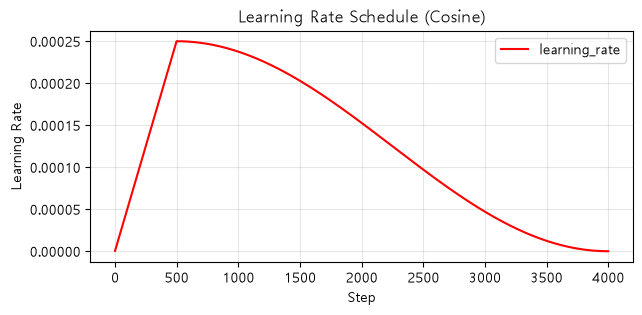

In [34]:
class CosineSchedule:
    """
    warmup 동안 선형으로 올린 뒤 cosine 으로 0 까지 줄이는 learning rate 스케줄
    """
    def __init__(self, optimizer=None, train_steps=4000, warmup_steps=500, max_lr=2.5e-4):
        """
        생성자
        :param optimizer: Optimizer (step() 마다 lr 을 적용)
        :param train_steps: 총 학습 step 수
        :param warmup_steps: warmup steps
        :param max_lr: 최대 learning rate
        """
        self.optimizer = optimizer
        self.train_steps = train_steps
        self.warmup_steps = warmup_steps
        self.max_lr = max_lr
        self.step_num = 0

    def get_lr(self):
        """
        learning rate 계산
        :return: 계산된 learning rate
        """
        if self.step_num <= self.warmup_steps:
            lr = (self.step_num / self.warmup_steps) * self.max_lr
        else:
            progress = (self.step_num - self.warmup_steps) / max(1, self.train_steps - self.warmup_steps)
            lr = 0.5 * self.max_lr * (1 + math.cos(math.pi * progress))
        return lr

    def step(self):
        """
        매 학습 step 마다 optimizer.step() 전에 호출 : lr 을 계산해 optimizer 에 적용하고 돌려준다
        """
        self.step_num += 1
        lr = self.get_lr()
        if self.optimizer is not None:
            for group in self.optimizer.param_groups:
                group['lr'] = lr
        return lr


# Learning Rate 시각화
test_schedule = CosineSchedule(train_steps=4000, warmup_steps=500)
lrs = [test_schedule.step() for _ in range(4000)]

plt.figure(figsize=(7, 3))
plt.plot(lrs, 'r-', label='learning_rate')
plt.xlabel('Step'); plt.ylabel('Learning Rate')
plt.title('Learning Rate Schedule (Cosine)')
plt.legend(); plt.grid(alpha=.3)
plt.show()

### 8-3. DataLoader

- 5%를 validation으로 뗀다 (시드 고정). 1-3 `SPLIT`이 `'instance'`면 인스턴스 단위 무작위(실험 1), `'doc'`이면 문서 단위(실험 2~)로 나눠 한 문서의 인스턴스가 train과 val에 함께 들어가지 않게 한다.
- `BatchSampler`로 인덱스 묶음을 한 번에 넘겨 GPU 텐서를 배치 단위로 한 번에 자른다. `TensorDataset` 방식보다 빠르다.

In [35]:
from torch.utils.data import BatchSampler, RandomSampler, SequentialSampler

BATCH_SIZE = 64
VAL_RATIO = 0.05


def make_loader(tensors, batch_size, shuffle, seed=SEED):
    """GPU 텐서들을 배치 단위로 잘라 주는 DataLoader (dataset[list] 로 한 번에 인덱싱)"""
    dataset = TensorDataset(*tensors)
    if shuffle:
        base = RandomSampler(dataset, generator=torch.Generator().manual_seed(seed))
    else:
        base = SequentialSampler(dataset)
    return DataLoader(dataset, sampler=BatchSampler(base, batch_size, drop_last=False), batch_size=None)


def load_doc_ids(filename, count=None):
    """pretrain json 앞에서부터 count 개 인스턴스의 doc_id"""
    with open(filename, 'r', encoding='utf-8') as f:
        return np.array([json.loads(line)['doc_id'] for line in islice(f, count)], dtype=np.int64)


def split_by_doc(doc_ids, val_ratio, seed=SEED):
    """문서를 무작위 순서로 val 에 넣어 인스턴스 수가 val_ratio 에 닿을 때까지 모은다. 한 문서의 인스턴스는 모두 한쪽에만 들어간다."""
    docs, counts = np.unique(doc_ids, return_counts=True)
    order = np.random.default_rng(seed).permutation(len(docs))
    n_take = np.searchsorted(np.cumsum(counts[order]), int(len(doc_ids) * val_ratio)) + 1
    is_val = np.isin(doc_ids, docs[order[:n_take]])
    return np.where(~is_val)[0], np.where(is_val)[0]


# (enc_tokens, segments, labels_nsp, labels_mlm) memmap -> tensor
data_tensors = [torch.from_numpy(np.array(x)) for x in (*pre_train_inputs, *pre_train_labels)]
if SPLIT == 'doc':
    doc_ids = load_doc_ids(pretrain_json_path, count=len(data_tensors[0]))
    train_idx, val_idx = (torch.from_numpy(x) for x in split_by_doc(doc_ids, VAL_RATIO))
    train_docs, val_docs = set(doc_ids[train_idx.numpy()].tolist()), set(doc_ids[val_idx.numpy()].tolist())
    assert not train_docs & val_docs
    print(f'문서  : train {len(train_docs):,} / val {len(val_docs):,} (겹침 없음)')
else:                                   # 인스턴스 단위 무작위 (실험 1)
    perm = torch.randperm(len(data_tensors[0]), generator=torch.Generator().manual_seed(SEED))
    n_val = int(len(perm) * VAL_RATIO)
    val_idx, train_idx = perm[:n_val], perm[n_val:]

train_loader = make_loader([t[train_idx].to(device) for t in data_tensors], BATCH_SIZE, shuffle=True)
val_loader = make_loader([t[val_idx].to(device) for t in data_tensors], 256, shuffle=False)
del data_tensors

print(f'train : {len(train_idx):,}개 / {len(train_loader):,} batch')
print(f'val   : {len(val_idx):,}개 ({len(val_idx) / (len(train_idx) + len(val_idx)):.2%}) / {len(val_loader):,} batch')
batch = next(iter(train_loader))
print('batch :', [tuple(t.shape) for t in batch], batch[0].device)

문서  : train 26,328 / val 1,372 (겹침 없음)
train : 121,599개 / 1,900 batch
val   : 6,401개 (5.00%) / 26 batch
batch : [(64, 128), (64, 128), (64,), (64, 128)] cuda:0


### 8-4. 학습 루프

- **step 단위로 NSP / MLM loss · accuracy · lr을 기록**하여 loss가 안정적으로 줄어드는지 확인한다.
- 학습 초반 loss가 튀는 것을 막기 위해서 gradient norm을 1.0으로 자른다 (`clip_grad_norm_`).
- epoch마다 `models/{RUN_NAME}_epoch_{n}.pt` 저장, 학습 기록은 `data/history/{RUN_NAME}.json`에 저장한다.

In [36]:
import time

METRICS = ('nsp_loss', 'mlm_loss', 'nsp_acc', 'mlm_acc')


def run_batch(model, batch):
    """배치 하나의 NSP / MLM loss · accuracy 를 계산한다."""
    enc_tokens, segments, labels_nsp, labels_mlm = batch
    logits_nsp, logits_mlm = model(enc_tokens, segments)
    return {
        'nsp_loss': nsp_loss(labels_nsp, logits_nsp),
        'mlm_loss': lm_loss(labels_mlm, logits_mlm),
        'nsp_acc': nsp_acc(labels_nsp, logits_nsp),
        'mlm_acc': lm_acc(labels_mlm, logits_mlm),
    }


@torch.no_grad()
def evaluate(model, loader):
    """loader 전체 지표. 배치별 평균을 다시 단순 평균한다.

    배치 크기가 다르면 작은 마지막 배치가 과대 반영된다
    (실험 2 val 6,401개 = 256 × 25 + 1 이라 마지막 1개가 1/26 가중치를 갖는다).
    """
    model.eval()
    sums = Counter()
    for batch in loader:
        for k, v in run_batch(model, batch).items():
            sums[k] += v.item()
    return {k: sums[k] / len(loader) for k in METRICS}


def train_one_epoch(model, loader, optimizer, scheduler, step_log, clip=1.0):
    """1 epoch 학습. step 마다 지표와 lr 을 step_log 에 추가하고 epoch 평균을 돌려준다."""
    model.train()
    sums = Counter()
    for batch in tqdm(loader, desc='train', leave=False, mininterval=1):
        lr = scheduler.step()                   # 이번 step 의 lr 을 optimizer 에 먼저 적용
        out = run_batch(model, batch)
        loss = out['nsp_loss'] + out['mlm_loss']

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()

        vals = {k: v.item() for k, v in out.items()}
        step_log.append({'step': scheduler.step_num, 'lr': lr, **vals})
        for k, v in vals.items():
            sums[k] += v
    return {k: sums[k] / len(loader) for k in METRICS}


def run_pretrain(model, config, train_loader, val_loader, epochs, max_lr, warmup_ratio=0.1, run_name='mini_bert'):
    """
    pretrain 실행. epoch 마다 체크포인트 · 학습 기록을 저장하고 기록(history)을 돌려준다.
    :param model: PreTrainModel
    :param config: Config (history 에 함께 저장)
    :param train_loader: 학습 DataLoader
    :param val_loader: 검증 DataLoader (학습 전 epoch 0 과 매 epoch 끝에 평가)
    :param epochs: epoch 수
    :param max_lr: CosineSchedule 최대 lr
    :param warmup_ratio: 전체 step 중 warmup 비율
    :param run_name: 체크포인트 models/{run_name}_epoch_{n}.pt · 기록 data/history/{run_name}.json 의 이름
    :return history: dict(run_name, config, hparams, epochs, steps)
    """
    optimizer = optim.Adam(model.parameters(), lr=max_lr)      # lr 은 매 step CosineSchedule 이 덮어쓴다
    train_steps = len(train_loader) * epochs
    warmup_steps = int(train_steps * warmup_ratio)
    scheduler = CosineSchedule(optimizer, train_steps=train_steps, warmup_steps=warmup_steps, max_lr=max_lr)

    history = {
        'run_name': run_name, 'config': dict(config),
        'hparams': dict(epochs=epochs, batch_size=train_loader.sampler.batch_size, max_lr=max_lr,
                        train_steps=train_steps, warmup_steps=warmup_steps),
        'epochs': [], 'steps': [],
    }
    hist_path = os.path.join(HIST_DIR, f'{run_name}.json')
    print(f'train steps {train_steps:,} (warmup {warmup_steps:,}) | params {sum(p.numel() for p in model.parameters()):,}')

    val0 = evaluate(model, val_loader)          # 학습 전
    history['epochs'].append({'epoch': 0, **{f'val_{k}': v for k, v in val0.items()}})

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr = train_one_epoch(model, train_loader, optimizer, scheduler, history['steps'])
        va = evaluate(model, val_loader)
        history['epochs'].append({'epoch': epoch, 'time': time.time() - t0,
                                  **{f'train_{k}': v for k, v in tr.items()},
                                  **{f'val_{k}': v for k, v in va.items()}})
        print(f"[{epoch:>2}/{epochs}] "
              f"train NSP {tr['nsp_loss']:.4f} ({tr['nsp_acc']:.2%}) MLM {tr['mlm_loss']:.4f} ({tr['mlm_acc']:.2%}) | "
              f"val NSP {va['nsp_loss']:.4f} ({va['nsp_acc']:.2%}) MLM {va['mlm_loss']:.4f} ({va['mlm_acc']:.2%}) | "
              f"{time.time() - t0:.0f}s")

        torch.save(model.state_dict(), os.path.join(MODEL_DIR, f'{run_name}_epoch_{epoch}.pt'))
        with open(hist_path, 'w', encoding='utf-8') as f:
            json.dump(history, f)
    return history

### 8-5. 학습 (10 epoch)

In [37]:
EPOCHS = 10
MAX_LR = 2.5e-4
WARMUP_RATIO = 0.1

set_seed()
pre_train_model = PreTrainModel(config).to(device)
history = run_pretrain(pre_train_model, config, train_loader, val_loader,
                       EPOCHS, MAX_LR, WARMUP_RATIO, RUN_NAME)

train steps 19,000 (warmup 1,900) | params 969,120


train:   0%|          | 0/1900 [00:00<?, ?it/s]

[ 1/10] train NSP 0.6934 (49.87%) MLM 7.7127 (4.25%) | val NSP 0.6929 (51.31%) MLM 7.1540 (6.40%) | 73s


train:   0%|          | 0/1900 [00:00<?, ?it/s]

[ 2/10] train NSP 0.6933 (50.09%) MLM 6.9070 (9.10%) | val NSP 0.6931 (51.46%) MLM 6.6973 (11.64%) | 75s


...

[ 8/10] train NSP 0.6060 (61.59%) MLM 6.2743 (13.17%) | val NSP 0.6325 (56.55%) MLM 6.3970 (13.29%) | 72s


train:   0%|          | 0/1900 [00:00<?, ?it/s]

[ 9/10] train NSP 0.6003 (62.12%) MLM 6.2630 (13.19%) | val NSP 0.6368 (60.47%) MLM 6.3960 (13.08%) | 77s


train:   0%|          | 0/1900 [00:00<?, ?it/s]

[10/10] train NSP 0.5967 (62.63%) MLM 6.2584 (13.21%) | val NSP 0.6387 (56.67%) MLM 6.3951 (13.30%) | 76s


---
# 9. 결과 시각화

### 9-1. epoch별 NSP / MLM loss · accuracy

epoch 0은 학습 전 validation 값이다.

,val_nsp_loss,val_mlm_loss,val_nsp_acc,val_mlm_acc,train_nsp_loss,train_mlm_loss,train_nsp_acc,train_mlm_acc
epoch,,,,,,,,
0,0.6937,8.9107,0.4869,0.0938,-,-,-,-
1,0.6929,7.1540,0.5131,0.0640,0.6934,7.7127,0.4987,0.0425
2,0.6931,6.6973,0.5146,0.1164,0.6933,6.9070,0.5009,0.0910
3,0.6932,6.5375,0.5174,0.1264,0.6932,6.5861,0.5031,0.1186
4,0.6763,6.4746,0.5445,0.1296,0.6898,6.4524,0.5230,0.1260
5,0.6418,6.4381,0.5944,0.1309,0.6546,6.3790,0.5715,0.1283
6,0.6352,6.4127,0.5675,0.1302,0.6279,6.3272,0.5929,0.1299
7,0.6349,6.4019,0.5696,0.1305,0.6153,6.2947,0.6062,0.1310
8,0.6325,6.3970,0.5655,0.1329,0.6060,6.2743,0.6159,0.1317


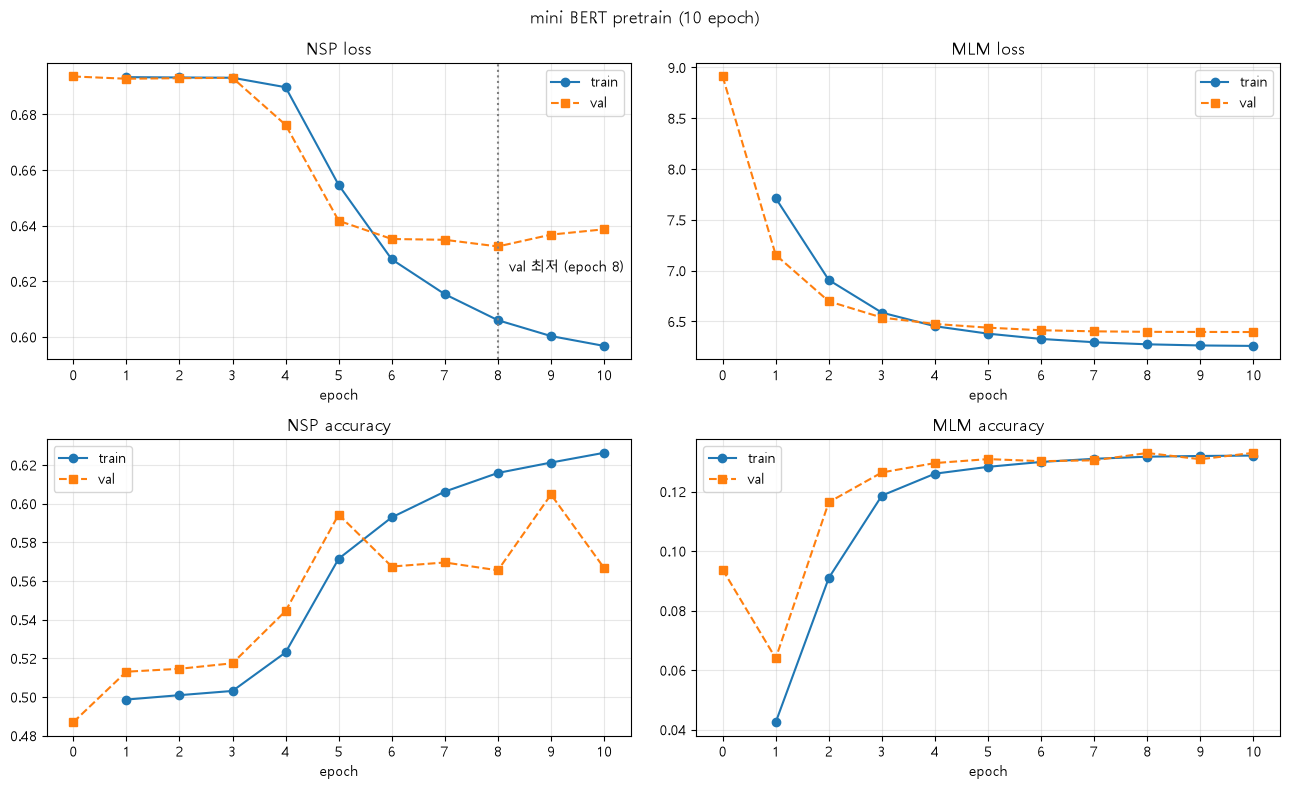

val NSP loss 최저 : epoch 8 (0.6325) -> epoch 10 (0.6387)
val MLM loss      : 학습 전 8.9107 -> epoch 10 6.3951


In [38]:
ep = pd.DataFrame(history['epochs']).set_index('epoch').drop(columns='time', errors='ignore')
display(ep.style.format('{:.4f}', na_rep='-'))

best_nsp = ep['val_nsp_loss'].iloc[1:].idxmin()

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
panels = [('nsp_loss', 'NSP loss'), ('mlm_loss', 'MLM loss'), ('nsp_acc', 'NSP accuracy'), ('mlm_acc', 'MLM accuracy')]
for ax, (metric, title) in zip(axes.flat, panels):
    ax.plot(ep.index, ep[f'train_{metric}'], 'o-', label='train')
    ax.plot(ep.index, ep[f'val_{metric}'], 's--', label='val')
    ax.set_title(title); ax.set_xlabel('epoch'); ax.set_xticks(ep.index)
    ax.grid(alpha=.3); ax.legend()
axes[0, 0].axvline(best_nsp, color='gray', ls=':')
axes[0, 0].annotate(f'val 최저 (epoch {best_nsp})', (best_nsp, ep.loc[best_nsp, 'val_nsp_loss']),
                    textcoords='offset points', xytext=(8, -18))
plt.suptitle(f"mini BERT pretrain ({history['hparams']['epochs']} epoch)")
plt.tight_layout()
plt.show()

print(f"val NSP loss 최저 : epoch {best_nsp} ({ep.loc[best_nsp, 'val_nsp_loss']:.4f}) -> epoch {ep.index[-1]} ({ep['val_nsp_loss'].iloc[-1]:.4f})")
print(f"val MLM loss      : 학습 전 {ep['val_mlm_loss'].iloc[0]:.4f} -> epoch {ep.index[-1]} {ep['val_mlm_loss'].iloc[-1]:.4f}")

### 9-2. MLM 예측 예시 · 대체 방식별 정확도

- 짧은 validation 인스턴스 2개에서 마스크 위치마다 입력 · 정답 · top-5 예측 · 정답 순위를 확인한다.
- validation 전체에서 마스크 위치를 대체 방식(`[MASK]` / random / 원래 토큰)별로 나눠 top-1 · top-5 accuracy와 입력 토큰을 그대로 예측한 비율을 계산한다.
- 기준선으로 가장 흔한 정답 토큰 하나만 예측했을 때의 accuracy를 사용한다.

In [41]:
MASK_ID = vocab.piece_to_id('[MASK]')
KINDS = ['[MASK]', 'random', '원래 토큰']
val_enc, val_seg, val_nsp, val_mlm = val_loader.dataset.tensors
val_len = (val_enc != 0).sum(dim=1)
pre_train_model.eval()


def decode_ids(ids):
    """id -> 문자열 (pad 제외, [MASK] 등 특수 토큰은 그대로 보인다)"""
    return vocab.decode_pieces([vocab.id_to_piece(int(i)) for i in ids if int(i) != 0])


def mask_kind(in_id, label_id):
    """마스크 위치의 입력 id · 정답 id 로 대체 방식([MASK] / 원래 토큰 / random)을 판단한다."""
    return '[MASK]' if in_id == MASK_ID else ('원래 토큰' if in_id == label_id else 'random')


@torch.no_grad()
def show_mlm(idx, topk=5):
    """val 인스턴스 하나의 마스크 위치별 top-k 예측 (전역 pre_train_model 사용)"""
    enc, seg, lab = val_enc[idx:idx + 1], val_seg[idx:idx + 1], val_mlm[idx]
    _, logits = pre_train_model(enc, seg)
    prob = logits[0].softmax(dim=-1)
    print(f'[val {idx}] 길이 {int(val_len[idx])}')
    print('  입력 :', decode_ids(enc[0]))
    rows = []
    for pos in (lab != 0).nonzero().flatten().tolist():
        p, ids = prob[pos].topk(topk)
        label_id, in_id = int(lab[pos]), int(enc[0, pos])
        rows.append({
            '위치': pos, '대체': mask_kind(in_id, label_id),
            '입력': vocab.id_to_piece(in_id), '정답': vocab.id_to_piece(label_id),
            f'top-{topk} (확률)': ', '.join(f'{vocab.id_to_piece(int(i))} {float(q):.2f}' for i, q in zip(ids, p)),
            '정답 순위': int((prob[pos] > prob[pos, label_id]).sum()) + 1,
        })
    display(pd.DataFrame(rows).set_index('위치'))


for idx in (val_len <= 64).nonzero().flatten()[:2].tolist():
    show_mlm(idx)

[val 7] 길이 45
  입력 : [CLS] 여기서 합은 "x"보다[MASK][MASK] 같은[MASK] 양의 정수 "n"에 대해서 이루어진다.[SEP][MASK] 만족하면, 1보다 크거나[MASK][MASK] formula_16에 대해 이 성립한다.[SEP]


,대체,입력,정답,top-5 (확률),정답 순위
위치,,,,,
8,[MASK],[MASK],▁작,". 0.07, "" 0.06, ▁"" 0.06, ▁ 0.02, 의 0.02",974
9,[MASK],[MASK],거나,". 0.07, "" 0.06, ▁"" 0.06, ▁ 0.02, 의 0.02",529
11,[MASK],[MASK],▁모든,". 0.07, ▁"" 0.06, "" 0.06, ▁ 0.02, 의 0.02",95
25,[MASK],[MASK],▁을,"▁formula 0.06, . 0.05, _1 0.03, _ 0.03, 의 0.02",755
33,[MASK],[MASK],▁같은,"▁formula 0.06, . 0.05, _1 0.03, _ 0.03, 의 0.02",37
34,[MASK],[MASK],▁모든,"▁formula 0.06, . 0.05, _1 0.03, _ 0.03, 의 0.02",59


[val 23] 길이 61
  입력 : [CLS] 집합 formula_1[MASK] 동치관계 formula_2에 대하여, 그 몫집합 formula_20은 formula_1의 분할이다.[MASK][MASK] 반대로, 집합[MASK][MASK][MASK] 분할 formula_44에 대하여, 이항관계[SEP] 는 동치관계이다.[SEP]


,대체,입력,정답,top-5 (확률),정답 순위
위치,,,,,
4,[MASK],[MASK],▁위의,"▁formula 0.11, _1 0.04, _ 0.04, . 0.04, , 0.03",23
30,[MASK],[MASK],▁즉,"▁formula 0.12, . 0.05, _1 0.04, _ 0.04, , 0.03",57
31,[MASK],[MASK],",","▁formula 0.12, . 0.05, _1 0.04, _ 0.03, , 0.03",5
36,[MASK],[MASK],▁formula,"▁formula 0.12, . 0.05, _1 0.04, _ 0.03, , 0.03",1
37,[MASK],[MASK],_1,"▁formula 0.12, . 0.05, _1 0.04, _ 0.03, , 0.03",3
38,[MASK],[MASK],의,"▁formula 0.12, . 0.05, _1 0.04, _ 0.03, , 0.03",7
52,원래 토큰,▁,▁,"▁ 0.99, , 0.00, 의 0.00, 는 0.00, 을 0.00",1
53,원래 토큰,는,는,"는 0.98, 은 0.00, 의 0.00, 을 0.00, ▁ 0.00",1


In [42]:
@torch.no_grad()
def mlm_breakdown(model, loader, topk=5):
    """마스크 위치를 대체 방식별로 나눠 top-1 / top-k accuracy, 입력 토큰을 그대로 예측한 비율을 센다."""
    model.eval()
    n, hit1, hitk, copy = Counter(), Counter(), Counter(), Counter()
    pred_at_mask = Counter()                                    # [MASK] 위치에서 예측한 토큰
    for enc, seg, _, lab in loader:
        _, logits = model(enc, seg)
        m = lab != 0
        kind = torch.where(enc == MASK_ID, 0, torch.where(enc == lab, 2, 1))
        pred = logits.argmax(dim=-1)
        in_topk = (logits.topk(topk, dim=-1).indices == lab.unsqueeze(-1)).any(dim=-1)
        for k, name in enumerate(KINDS):
            sel = m & (kind == k)
            n[name] += sel.sum().item()
            hit1[name] += (sel & (pred == lab)).sum().item()
            hitk[name] += (sel & in_topk).sum().item()
            copy[name] += (sel & (pred == enc)).sum().item()
        pred_at_mask.update(pred[m & (kind == 0)].tolist())

    df = pd.DataFrame({'개수': n, 'top-1 acc': hit1, f'top-{topk} acc': hitk, '입력 토큰을 그대로 예측': copy}).loc[KINDS]
    df.loc['전체'] = df.sum()
    for col in df.columns[1:]:
        df[col] = df[col] / df['개수']
    return df, pred_at_mask


mlm_df, pred_at_mask = mlm_breakdown(pre_train_model, val_loader)
display(mlm_df.style.format({'개수': '{:,.0f}', 'top-1 acc': '{:.2%}', 'top-5 acc': '{:.2%}', '입력 토큰을 그대로 예측': '{:.2%}'}))

# 기준선 : 가장 흔한 정답 토큰 하나만 예측
label_counts = Counter(val_mlm[val_mlm != 0].tolist())
top_id, top_cnt = label_counts.most_common(1)[0]
print(f'기준선 - 가장 흔한 정답 "{vocab.id_to_piece(top_id)}" 만 예측 : {top_cnt / sum(label_counts.values()):.2%}')

n_mask_pos = sum(pred_at_mask.values())
print(f'[MASK] 위치에서 가장 많이 예측한 토큰 10개 (서로 다른 예측 토큰 {len(pred_at_mask):,}개) :')
print('  ' + ', '.join(f'{vocab.id_to_piece(i)} {c / n_mask_pos:.1%}' for i, c in pred_at_mask.most_common(10)))

,개수,top-1 acc,top-5 acc,입력 토큰을 그대로 예측
[MASK],"89,944",3.88%,9.90%,0.00%
random,"11,292",1.58%,5.59%,45.86%
원래 토큰,"11,409",97.84%,98.68%,97.84%
전체,"112,645",13.16%,18.46%,14.51%


기준선 - 가장 흔한 정답 "." 만 예측 : 2.87%
[MASK] 위치에서 가장 많이 예측한 토큰 10개 (서로 다른 예측 토큰 191개) :
  . 44.7%, , 29.1%, 년 5.5%, 을 3.0%, ▁ 2.4%, 의 2.1%, ( 1.5%, ) 1.5%, 월 1.1%, 은 0.9%


### 9-3. NSP 예측 (IsNext / NotNext)

- validation 전체의 confusion matrix와 P(IsNext) 분포를 본다.
- A 또는 B가 짧은 경우(8토큰 이하, 대부분 문서 제목)와 나머지의 정확도를 나눠서 확인한다.
- 짧은 인스턴스로 IsNext / NotNext 예시를 2개씩 본다.

val NSP accuracy : 58.93%


예측,IsNext,NotNext
정답,,
IsNext,2193,1048
NotNext,1581,1579


A 또는 B 가 8토큰 이하 :  1.17% of val | acc 58.67%
나머지             : 98.83% of val | acc 58.93%


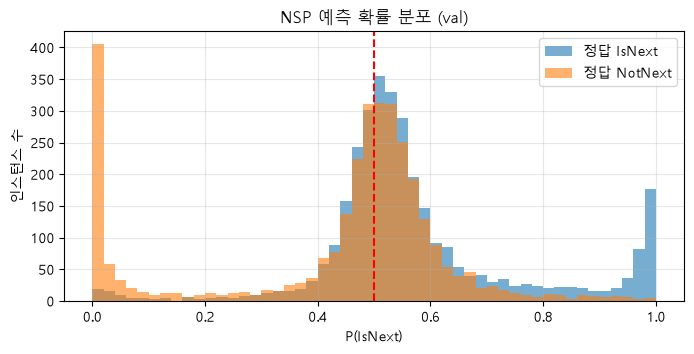

[val 23] 정답 IsNext | P(IsNext) 0.60 | O
  A : 집합 formula_1[MASK] 동치관계 formula_2에 대하여, 그 몫집합 formula_20은 formula_1의 분할이다.[MASK][MASK] 반대로, 집합[MASK][MASK][MASK] 분할 formula_44에 대하여, 이항관계
  B : 는 동치관계이다.
[val 155] 정답 IsNext | P(IsNext) 0.67 | O
  A : [MASK][MASK] 27일은 그레고리력으로 117번째(윤년일[MASK] 118번째) 날에 해당한다.
  B : 축구선수 스티븐 제라드가뛰 경우도 기어가서뎀바 바의 개 훔바훔바로 불리게 되었다.위고[MASK][MASK][MASK][MASK]
[val 7] 정답 NotNext | P(IsNext) 0.56 | X
  A : 여기서 합은 "x"보다[MASK][MASK] 같은[MASK] 양의 정수 "n"에 대해서 이루어진다.
  B : [MASK] 만족하면, 1보다 크거나[MASK][MASK] formula_16에 대해 이 성립한다.
[val 152] 정답 NotNext | P(IsNext) 0.54 | X
  A : 모든 달이 1번째 요일에 시작한다는[MASK] 만들었으며,[MASK] 년도는 없다.
  B : 이 페이지는 날짜 페이지로 가는 링크를 모아놓은 페이지이다.


In [43]:
@torch.no_grad()
def nsp_predict(model, loader):
    """loader 전체의 P(IsNext) 와 정답"""
    model.eval()
    probs, labels = [], []
    for enc, seg, nsp, _ in loader:
        logits_nsp, _ = model(enc, seg)
        probs.append(logits_nsp.softmax(dim=-1)[:, 1].cpu())
        labels.append(nsp.cpu())
    return torch.cat(probs).numpy(), torch.cat(labels).numpy()


p_next, y_next = nsp_predict(pre_train_model, val_loader)
pred_next = (p_next >= 0.5).astype(int)
names = {0: 'NotNext', 1: 'IsNext'}
cm = pd.crosstab(pd.Series(y_next, name='정답').map(names), pd.Series(pred_next, name='예측').map(names))
print(f'val NSP accuracy : {(pred_next == y_next).mean():.2%}')
display(cm)

# A / B 길이별 정확도 (pad 도 segment 0 이라 enc != 0 으로 거른다)
nonpad = val_enc != 0
len_a = ((val_seg == 0) & nonpad).sum(dim=1).cpu().numpy() - 2      # [CLS], [SEP] 제외
len_b = ((val_seg == 1) & nonpad).sum(dim=1).cpu().numpy() - 1      # [SEP] 제외
short = np.minimum(len_a, len_b) <= 8
for name, sel in [('A 또는 B 가 8토큰 이하', short), ('나머지', ~short)]:
    print(f'{name:<16}: {sel.mean():6.2%} of val | acc {(pred_next[sel] == y_next[sel]).mean():.2%}')

fig, ax = plt.subplots(figsize=(8, 3.5))
for label in (1, 0):
    ax.hist(p_next[y_next == label], bins=50, range=(0, 1), alpha=.6, label=f'정답 {names[label]}')
ax.axvline(0.5, color='r', ls='--')
ax.set_xlabel('P(IsNext)'); ax.set_ylabel('인스턴스 수'); ax.set_title('NSP 예측 확률 분포 (val)')
ax.legend(); ax.grid(alpha=.3)
plt.show()


def split_ab(idx):
    """val 인스턴스의 A / B 문자열 ([CLS], [SEP] 제외)"""
    n = int(val_len[idx])
    ids, seg = val_enc[idx, :n].tolist(), val_seg[idx, :n].tolist()
    a = [i for i, s in zip(ids, seg) if s == 0][1:-1]
    b = [i for i, s in zip(ids, seg) if s == 1][:-1]
    return decode_ids(a), decode_ids(b)


short_idx = (val_len <= 64).nonzero().flatten().tolist()
for label in (1, 0):
    for idx in [i for i in short_idx if y_next[i] == label][:2]:
        a, b = split_ab(idx)
        ok = 'O' if pred_next[idx] == y_next[idx] else 'X'
        print(f'[val {idx}] 정답 {names[label]} | P(IsNext) {p_next[idx]:.2f} | {ok}')
        print('  A :', a)
        print('  B :', b)

---
# 10. 결과 해석

최종 결과는 **실험 2**(문서 첫 줄 제거 · 문서 단위 validation) 기준이다. 실험 2의 전체 NSP accuracy는 실험 1보다 낮다 (62.42% → 58.93%). 하지만 실험 1의 수치는 제목 단서(짧은 쌍 96.88%)와 같은 문서를 공유하는 val로 부풀려져 있었다. 두 가지를 없앤 실험 2가 모델의 실제 수준을 더 정직하게 보여 준다.

| 루브릭 | 결과 | 근거 (섹션) |
|---|---|---|
| 1. MLM · NSP 특징이 반영된 pretrain 데이터셋 | kowiki 502,261개 문서 → 인스턴스 659,659개. **MLM** : 띄어쓰기 단위 마스킹, 대체 방식 `[MASK]` 79.98% / random 9.97% / 원래 토큰 10.06% (목표 80 / 10 / 10). **NSP** : 문서 안 연속 줄을 A / B로 나누고 50% 순서 뒤집기 (IsNext 49.96%), segment A = 0 / B = 1. 학습 데이터 128,000개 구조 검사 8개 항목 100% 통과. | 4-3, 5-3, 6-4 |
| 2. MLM · NSP loss의 안정적인 감소 | 10 epoch 동안 발산 · 급등 없이 학습했다. **MLM** : train · val loss가 매 epoch 줄었다 (val 8.911 → 6.395). **NSP** : epoch 1 ~ 3은 0.693(= ln 2)에서 줄지 않다가 epoch 4부터 줄었다 (val 0.693 → 0.639, train → 0.597). epoch 6 이후 val은 0.632 ~ 0.639로 평평하다 | 8-5, 9-1 |
| 3. 1M mini BERT 제작 · 학습, 시각화 제출 | 파라미터 969,120개 (d_model 80 · 4층 · 4 head · d_ff 320). 10 epoch 학습, epoch별 체크포인트 저장. 시각화 : lr 스케줄, epoch별 loss · accuracy, MLM 대체 방식별 정확도, NSP 예측 확률 분포 | 7-5, 8-2, 8-5, 9 |

### 최종 설정 (실험 2)

| 항목 | 값 |
|---|---|
| vocab | 8,000 (+ 특수 토큰 7개 = 8,007) |
| config | d_model 80 · n_layer 4 · n_head 4 (d_head 20) · d_ff 320 · dropout 0.1 · n_seq 128 |
| 파라미터 수 | 969,120 (공유 token embedding 66.1% · encoder 32.1%) |
| 학습 데이터 | 문서 첫 줄(제목) 제거, 파일 앞 128,000개 → train 121,599 / val 6,401 (문서 단위 분할) |
| 학습 | batch 64 · Adam · max_lr 2.5e-4 · warmup 10% + cosine · grad clip 1.0 · 10 epoch (19,000 step) |
| 최종 (val, epoch 10) | NSP loss 0.639 · acc 58.93% / MLM loss 6.395 · acc 13.16% |

### 한계

- **MLM은 문맥으로 단어를 복원하지 못한다.** accuracy 13.16% 중 약 75%는 '원래 토큰' 위치를 그대로 옮겨 적어 맞힌 것이다. 실제로 가려진 `[MASK]` 위치의 top-1은 3.88%로 가장 흔한 토큰 `.`만 예측하는 기준선(2.87%)보다 약 1%p 높을 뿐이다. 예측의 73.8%가 `.` `,`다. train과 val 차이가 작아 과적합이 아니라 학습 부족이며, 모델 크기와 학습량의 문제로 보인다.
- **NSP는 무작위보다 약 9%p 높은 수준이다.** NotNext recall이 49.97%로 NotNext는 거의 구분하지 못한다. P(IsNext)가 0 또는 1 근처인 확신한 예측이 일부 있는데, 그 단서가 무엇인지는 확인하지 못했다.
- **데이터를 일부만, 고정된 마스크로 썼다.** 전체 659,659개 중 파일 앞부분 128,000개(19.4%)만 학습했고, 마스크가 json에 고정되어 10 epoch 동안 같은 마스크를 반복해서 봤다.

---
# 11. 실험


### 실험 기록

| # | 이름 | 바꾼 것 (기준선 대비) | 파라미터 수 | 최종 NSP loss / acc (val) | 최종 MLM loss / acc (val) | 결론 |
|---|---|---|---|---|---|---|
| 1 | base | - (기준선) | 969,120 | 0.651 / 62.42% | 6.458 / 13.06% | 학습은 안정적이나 MLM은 입력 복사 · 기호 위주 예측, NSP는 제목 단서에 의존하고 epoch 5부터 과적합 |
| 2 | notitle_docsplit | 문서 첫 줄(제목) 제거 · validation을 문서 단위로 분할 | 969,120 | 0.639 / 58.93% | 6.395 / 13.16% | 제목 단서가 사라져 NSP는 epoch 4부터 학습, 일반 쌍 54.86% → 58.93% · 과적합 감소. NotNext는 무작위 수준, MLM은 변화 없음 |


### 실험 1. base (기준선)

- 설정 : d_model 80 · n_layer 4 · d_ff 320 · n_head 4, 학습 128,000개 (train 121,600 / val 6,400), batch 64 · max_lr 2.5e-4 · warmup 10% · 10 epoch
- 수치는 validation 6,400개 · epoch 10 모델 기준이다.

#### 1-1. 학습 곡선

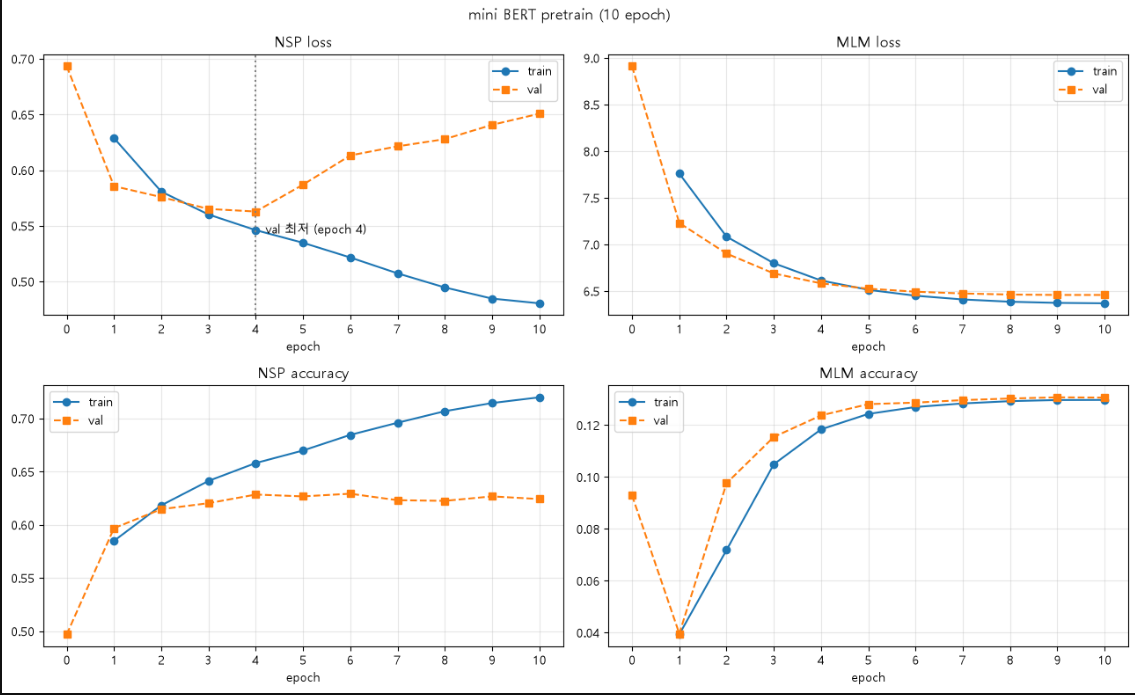

- **MLM**: train · val loss가 10 epoch 동안 매번 줄었다 (val 8.911 → 6.458). 마지막 train–val 차이는 0.09로 과적합은 없다.
- **NSP**: train loss는 계속 줄었지만 val loss는 epoch 4가 최저이고(0.563) 이후 올라 epoch 10에 0.651이 된다. val accuracy는 epoch 3부터 62~63%에서 멈췄다. epoch 5부터 과적합이다.

#### 1-2. MLM : loss는 줄었지만 가려진 단어는 거의 맞히지 못했다

| 마스크 위치의 대체 방식 | 개수 | top-1 acc | top-5 acc | 입력 토큰을 그대로 예측 |
|---|---|---|---|---|
| `[MASK]` | 85,475 (79.8%) | 3.97% | 9.93% | 0.00% |
| random | 10,739 | 1.70% | 6.12% | 45.84% |
| 원래 토큰 | 10,838 | 96.11% | 97.79% | 96.11% |
| **전체** | **107,052** | **13.07%** | **18.44%** | 14.33% |

- 전체 MLM accuracy 13.07%에서 맞힌 약 13,990개 중 약 74%는 '원래 토큰' 위치다. 입력 토큰을 그대로 옮겨 적어 맞힌 것이다.
- 실제로 가려진 `[MASK]` 위치의 top-1 accuracy는 3.97%로, 가장 흔한 정답 `.` 하나만 예측하는 기준선(2.98%)보다 약 1%p 높다.
- `[MASK]` 위치 예측의 65.4%가 `,`(36.2%)와 `.`(29.2%)이고, 예측에 쓰인 토큰은 8,007개 중 130개뿐이다.
- random으로 바뀐 위치의 45.84%에서 바뀐 입력 토큰을 그대로 예측했다. 입력 토큰을 정답으로 믿는 경향이 크다.
- 따라서 MLM accuracy 13%를 문맥으로 단어를 복원하는 능력으로 해석할 수 없다.

#### 1-3. NSP : 제목이 들어간 쌍만 맞히고, 일반 문장 쌍은 무작위 수준이다

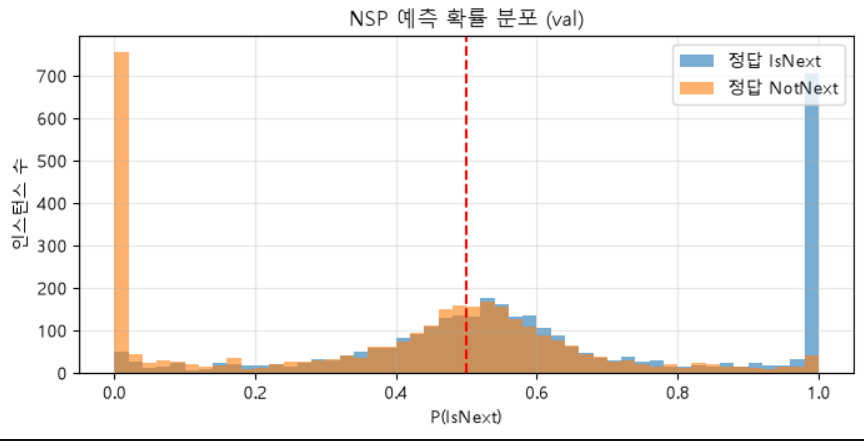

| val 인스턴스 | 비율 | NSP accuracy |
|---|---|---|
| A 또는 B가 8토큰 이하 (대부분 문서 제목) | 18.00% | 96.88% |
| 나머지 | 82.00% | 54.86% |
| **전체** | 100% | **62.42%** |

- 나머지 82%의 accuracy 54.86%는 무작위(50%)보다 4.86%p 높을 뿐이다. 전체 62.42%는 대부분 제목이 들어간 18%에서 나온다.
- 그래프 2에서 P(IsNext)가 0과 1에 몰린 확신한 예측과, 0.5 주변에서 IsNext와 NotNext가 거의 겹친 분포로 나뉜다. 9-3 예시 4개(모두 정답)도 전부 A 또는 B가 제목인 쌍이다.
- NotNext를 같은 문서 안에서 A / B 순서만 바꿔 만들었기 때문에 두 문장의 주제가 같다. 문서 제목은 짧고 다음 문장 첫머리에 반복되어 순서를 가리는 단서가 되는 것으로 보인다.
- train NSP accuracy는 72%까지 오르는데 val은 62%에서 멈춘 것은, 제목이 없는 쌍에서 일반화되는 규칙 없이 train 쌍을 외운 것으로 보인다.

#### 1-4. 요약

- 학습은 발산 없이 진행됐고 MLM · NSP train loss는 10 epoch 동안 계속 줄었다.
- 하지만 이 조건(파라미터 약 1M, 고정된 128,000개, 10 epoch)에서 MLM은 흔한 기호 위주로 예측하고, NSP는 제목 단서에 의존한다. 문맥 표현을 학습했다고 보기는 어렵다.

### 실험 2. 제목 줄 제거 + 문서 단위 validation

- 실험 1에서 NSP는 A 또는 B가 8토큰 이하인 쌍(문서 제목)만 맞혔다 (96.88%, 나머지 54.86%). 또 val을 인스턴스 단위로 뽑아 같은 문서의 다른 chunk가 train과 val에 함께 들어갔다.
- 바꾼 것 : ① 문서 첫 줄(제목)을 빼고 NSP 인스턴스 생성 ② validation을 문서 단위로 분할
- 그대로 둔 것 : tokenizer · config (969,120) · 파일 앞 128,000개 · batch 64 · max_lr 2.5e-4 · warmup 10% · 10 epoch · 시드
- 데이터 : 전체 인스턴스 659,659개 (실험 1 918,173개). A 또는 B가 8토큰 이하인 인스턴스 18.08% → **1.23%**. 구조 검사 8개 항목 통과
- 분할 : train 121,599개 (문서 26,328) / val 6,401개 (문서 1,372), 두 쪽에 같은 문서 없음
- 수치는 validation 6,401개 · epoch 10 모델 기준이다. 두 실험의 val 집합이 다르므로 수치 비교는 경향만 본다.


#### 2-1. 학습 곡선

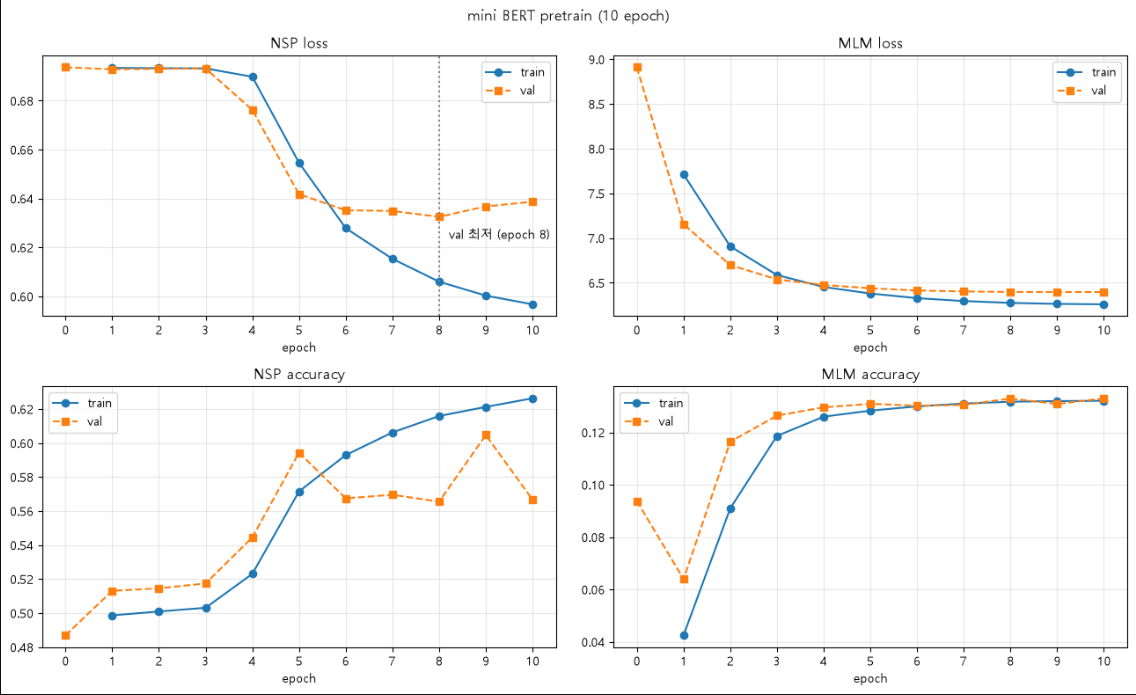

- **MLM**: train · val loss가 10 epoch 동안 줄었다 (val 8.911 → 6.395). epoch 7 이후 epoch당 감소폭은 0.005 이하다. 마지막 train–val 차이는 0.137로 실험 1(0.09)보다 조금 크다. val이 train에 없는 문서라서 더 엄격해진 영향으로 보이지만, 데이터도 함께 바뀌어 원인을 하나로 단정할 수는 없다.
- **NSP**: epoch 1~3은 train · val loss가 0.693(= ln 2)에 머물고 accuracy가 50~52%로, 전혀 학습하지 못했다. epoch 4부터 줄기 시작해 val loss는 epoch 6~10에 0.632~0.639로 거의 평평하다 (최저 epoch 8, 0.633). 제목이라는 쉬운 단서가 없어지자 학습 시작이 늦어진 것이다.
- train NSP loss는 끝까지 줄지만(0.597) val은 멈췄다. 과적합 조짐은 있지만, 최저점 이후 val loss 상승폭은 0.006으로 실험 1(0.563 → 0.651, +0.088)보다 훨씬 작다.


#### 2-2. MLM : 실험 1과 거의 같다

| 마스크 위치의 대체 방식 | 개수 | top-1 acc | top-5 acc | 입력 토큰을 그대로 예측 |
|---|---|---|---|---|
| `[MASK]` | 89,944 (79.8%) | 3.88% | 9.90% | 0.00% |
| random | 11,292 | 1.58% | 5.59% | 45.86% |
| 원래 토큰 | 11,409 | 97.84% | 98.68% | 97.84% |
| **전체** | **112,645** | **13.16%** | **18.46%** | 14.51% |

- 전체 accuracy 13.16%에서 맞힌 약 14,820개 중 약 75%가 '원래 토큰' 위치다 (실험 1 약 74%).
- `[MASK]` 위치 top-1 accuracy는 3.88%로 가장 흔한 정답 `.` 하나만 예측하는 기준선(2.87%)보다 약 1%p 높다 (실험 1 3.97% / 2.98%).
- `[MASK]` 위치 예측의 73.8%가 `.`(44.7%)와 `,`(29.1%)다. 예측에 쓰인 토큰은 191개로 실험 1(130개)보다 조금 늘었다.
- 9-2 예시에서 한 인스턴스의 `[MASK]` 위치 top-5가 위치와 상관없이 모두 같다 (val 7 : `.` `"` `▁"` …, val 23 : `▁formula` `.` `_1` …). 인스턴스에 어떤 토큰이 많은지는 반영하지만, 가려진 위치의 앞뒤 문맥은 거의 쓰지 못한다.
- 제목 제거와 val 분할은 MLM을 바꾸지 않는다. MLM의 한계는 데이터 구성이 아니다.
#### 2-3. NSP : 제목 단서를 없앴더니 일반 문장 쌍에서 조금 더 맞혔다

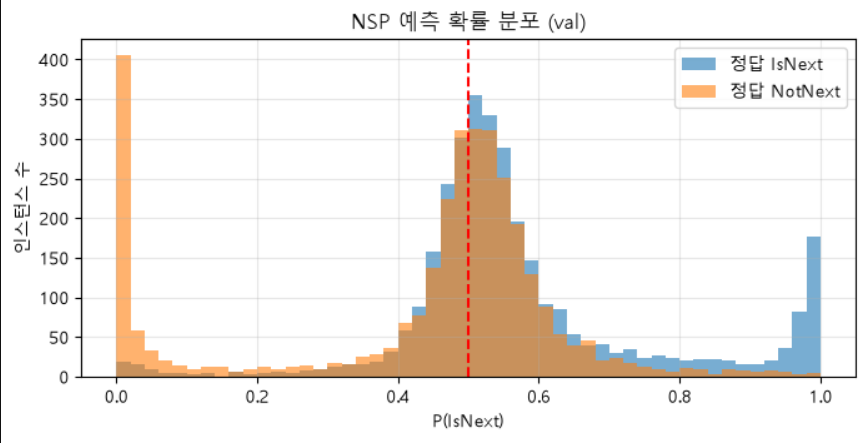

| val 인스턴스 | 비율 | NSP accuracy | 실험 1 (비율 / accuracy) |
|---|---|---|---|
| A 또는 B가 8토큰 이하 | 1.17% | 58.67% | 18.00% / 96.88% |
| 나머지 | 98.83% | 58.93% | 82.00% / 54.86% |
| **전체** | 100% | **58.93%** | 62.42% |

| 정답 / 예측 | IsNext | NotNext | recall |
|---|---|---|---|
| IsNext (3,241) | 2,193 | 1,048 | 67.66% |
| NotNext (3,160) | 1,581 | 1,579 | 49.97% |

- 짧은 쌍이 18.00% → 1.17%로 줄었고, 남은 짧은 쌍의 accuracy도 58.67%로 나머지와 같다.
- 전체 accuracy는 62.42% → 58.93%로 내려갔지만, 이는 제목 쌍에서 얻던 점수가 빠진 것이다. 일반 문장 쌍은 54.86% → 58.93%로 올랐다. val이 train에 없는 문서로 더 어려워졌는데도 올랐으므로, 쉬운 단서가 없어지자 문장 순서 자체를 조금 더 학습한 것이다.
- 예측이 IsNext 쪽으로 치우쳐 있다. IsNext recall은 67.66%인데 NotNext recall은 49.97%로 NotNext는 무작위 수준이다. 그래프에서도 대부분의 확률이 0.4~0.65에 겹쳐 있고 봉우리가 0.5보다 약간 오른쪽이다.
- train–val accuracy 차이는 3.70%p (train 62.63% / val 58.93%)로 실험 1(9.57%p)보다 작다. train 쌍을 외우는 정도가 줄었다.

#### 2-4. 요약

- 제목 줄을 빼자 NSP의 제목 단서가 사라졌다. 전체 accuracy는 내려갔지만 일반 문장 쌍의 accuracy는 오르고 과적합은 줄었다. 실험 1의 62.42%는 제목 단서로 부풀려진 값이었다.
- 그래도 NSP는 58.93%로 무작위보다 약 9%p 높은 수준이고, NotNext는 거의 구분하지 못한다. 확신한 일부 예측의 단서는 추가 확인이 필요하다.
- MLM은 두 실험에서 거의 같다. 여전히 흔한 기호 위주로 예측하고 문맥을 거의 쓰지 못한다.

---
# 12. 회고

- 데이터 전처리가 중요하다. 실험 1의 NSP accuracy 62.42%는 대부분 A 또는 B가 문서 제목인 짧은 쌍(96.88%)에서 나왔고, 나머지 쌍은 54.86%였다. 제목 줄을 빼자 전체 accuracy는 58.93%로 내려갔지만 일반 문장 쌍은 오히려 올랐다. 점수가 높은 설정보다 모델이 무엇으로 맞히는지를 확인할 수 있는 설정이 더 의미 있었다.
- MLM loss는 10 epoch 동안 계속 줄었지만, accuracy 13%를 대체 방식별로 나눠 보니 맞힌 것의 약 75%가 '원래 토큰' 위치를 그대로 옮겨 적은 것이었다. 가려진 위치의 가장 흔한 토큰인 기호만 예측하는 수준이었다. 정확도를 높이지 못한 점이 아쉽다.
- 전체 인스턴스 659,659개 중 파일 앞부분 128,000개만 학습 데이터로 사용했다. 전체 데이터를 사용하면 더 성능이 좋았을 것 같다.
- MLM이 문맥을 쓰지 못하는 원인이 무엇인지 확인하지 못했다. 한 인스턴스의 모든 `[MASK]` 위치에서 top-5가 똑같다는 것까지만 확인했다. 모델과 lr 등을 변경해보며 MLM의 성능이 올라가도록 시도할 계획이다.
